# Control Performance Monitoring (CPM) — GIMSCOP SISO — v6

Reproducible CPM pipeline applied to the [GIMSCOP SISO dataset](https://www.ufrgs.br/gimscop/)
published by UFRGS.

## Dataset variants

| File | Description |
|---|---|
| `SISO-RAW.h5` | Raw historian data — hierarchical layout, real timestamps, exception logging |
| `SISO-SEL.h5` | Curated fragments selected from RAW — same structure, shorter windows |
| **`SISO-SAMP.h5`** | SEL resampled to constant grid — flat layout, integer sample index |

**This notebook uses `SISO-SEL.h5`** for the 11 loops that have ≥ 59 h of continuous data,
enabling contemporaneous multi-loop analysis and temporal KPI monitoring.

## Why SEL and not SAMP?

SAMP contains fragments of 1–3 h per loop for most loops (with the exception of FIC38 at ~62 h), representing only 2–4% of the available SEL record, which prevents:

- Contemporaneous analysis (each fragment comes from a different time window)
- Temporal KPI monitoring (too short for rolling-window CPM)
- Reliable period estimation for slow oscillations (T > 30 min)

SEL retains real timestamps and the full signal structure of RAW, while providing
pre-selected, clean fragments. For the 11 loops analysed here, SEL contains
60 continuous hours of data (6–8 Oct 2017), all contemporaneous.

## KPI framework

### Oscillation
| KPI | Method | Reference |
|---|---|---|
| OI zero-crossing (OI_zc) | Zero-crossing rate of centred PV | Hägglund (1995) |
| OI regularity (OI_reg) | T / (3·σ_T) from ACF zero crossings | Thornhill, Huang & Zhang (2003) |
| Dominant period (T_osc) | FFT spectral peak | v5 |
| Period std dev (σ_T) | Variability of ACF zero-crossing intervals | — |
| Spectral power fraction (P_osc) | Power in ±1 octave band around f_dom | — |

### Valve activity
| KPI | Description |
|---|---|
| TV_norm | Normalised Total Variation of OP |
| TV_abs | Absolute Total Variation of OP |
| DCR | Direction Change Rate of OP |
| op_sat_frac | Empirical OP bound fraction (proxy for saturation) |

### Tracking error (SP coverage ≥ 5%)
| KPI | Formula |
|---|---|
| MAE | mean\|PV − SP\| |
| RMSE | √mean(PV − SP)² |
| Bias | mean(PV − SP) |
| IAE_norm | MAE / σ_PV |

### Positioner tracking (MV available)
| KPI | Description |
|---|---|
| op_mv_bias | Mean signed offset OP − MV |
| op_mv_mae | Mean absolute offset OP − MV |
| op_mv_corr | Pearson correlation OP vs MV |
| tv_mv_op_ratio | TV(MV) / TV(OP) — valve response indicator |
| mv_is_valve_position | Flag: False when tv_mv_op_ratio > 3.0 |

## Pipeline
1. Environment setup
2. Download & extract GIMSCOP archive
3. Dataset comparison (RAW / SEL / SAMP)
4. Loop selection — contemporaneous subset
5. Signal normalisation audit
6. SP rescaling for anomalous loops
7. Load, align and resample to regular grid
8. Window definition (8 h non-overlapping)
9. KPI reference guide
10. KPI helper functions
11. KPI computation — 11 loops × 7 windows
12. Results & visualisation
13. Export (windowed KPIs + loop summary + diagnosis flags)

All outputs are saved under `outputs/`.

---
> **Reference:** Dambros, J. W. V.; Trierweiler, J. O.; Farenzena, M.
> *Oscillation Detection in Process Industries – Part I: Review of the Detection Methods.*
> Journal of Process Control.


## 1. Environment Setup

In [1]:
import sys, subprocess

for pkg, imp in [("gdown", "gdown"), ("tables", "tables")]:
    try:
        __import__(imp)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import h5py
from pathlib import Path
from collections import defaultdict
import zipfile
import gdown
import tables  # noqa — required by pandas HDFStore

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.4f}".format)

DT_SECONDS = 2.059   # nominal sampling interval [s]

# Output directories
OUTPUTS_DIR = Path("outputs")
FIG_DIR     = OUTPUTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"numpy  {np.__version__}")
print(f"pandas {pd.__version__}")
print("Output directory set")


numpy  2.3.0
pandas 3.0.2
Output directory set


## 2. Download & Extract the GIMSCOP Archive

In [2]:
DATA_DIR    = Path("data_gimscop")
RAW_DIR     = DATA_DIR / "raw_download"
EXTRACT_DIR = DATA_DIR / "extracted"
for d in (RAW_DIR, EXTRACT_DIR):
    d.mkdir(parents=True, exist_ok=True)

GIMSCOP_FILE_ID = "1hnsj85dSJz344UyxbYcUlFi08xfhMALJ"
archive_path    = RAW_DIR / "SISO_datasets.zip"

if not archive_path.exists():
    print("Downloading GIMSCOP SISO archive (~204 MB)...")
    gdown.download(f"https://drive.google.com/uc?id={GIMSCOP_FILE_ID}",
                   str(archive_path), quiet=False)
else:
    print(f"Archive already present: {archive_path}")

print("Extracting...")
with zipfile.ZipFile(archive_path, "r") as zf:
    zf.extractall(EXTRACT_DIR)

FILES = {
    "RAW":  next(EXTRACT_DIR.rglob("*RAW*.h5")),
    "SEL":  next(EXTRACT_DIR.rglob("*SEL*.h5")),
    "SAMP": next(EXTRACT_DIR.rglob("*SAMP*.h5")),
}

print("\nDataset files:")
for name, path in FILES.items():
    print(f"  {name:4s}  {path.stat().st_size / 1e6:7.1f} MB  →  {path.name}")


Archive already present: data_gimscop\raw_download\SISO_datasets.zip
Extracting...

Dataset files:
  RAW     345.0 MB  →  SISO-RAW.h5
  SEL      96.0 MB  →  SISO-SEL.h5
  SAMP     12.8 MB  →  SISO-SAMP.h5


## 3. Dataset Comparison

Before selecting the working dataset, we audit the structure, signal layout and
sampling characteristics of the three variants.

### 3.1 Layout and signal inventory


In [3]:
CONTROL_SIGNALS = {"PV", "OP", "SP", "MV"}

def inventory_dataset(name, path):
    """Return a DataFrame with one row per loop and signal metadata."""
    with pd.HDFStore(path, mode="r") as store:
        all_keys = [k.lstrip("/") for k in store.keys()]

    # Robust layout detection: check whether any key ends with a control signal
    # after a "/" separator (RAW/SEL hierarchy), vs flat TAG_N keys (SAMP).
    is_hierarchical = any(
        "/" in k and k.split("/")[-1] in CONTROL_SIGNALS
        for k in all_keys
    )

    rows = []
    if is_hierarchical:
        loops = defaultdict(list)
        for k in all_keys:
            if "/" in k and k.split("/")[-1] in CONTROL_SIGNALS:
                tag = k.split("/")[0]
                sig = k.split("/")[-1]
                loops[tag].append(sig)
        for tag in sorted(loops.keys()):
            rows.append({"loop": tag, "n_signals": len(loops[tag]),
                         "signals": sorted(loops[tag])})
    else:
        segs = defaultdict(list)
        for k in all_keys:
            parts = k.rsplit("_", 1)
            tag = parts[0] if (len(parts) == 2 and parts[1].isdigit()) else k
            segs[tag].append(k)
        for tag in sorted(segs.keys()):
            with pd.HDFStore(path, mode="r") as store:
                df = store["/" + segs[tag][0]]
            rows.append({"loop": tag, "n_segs": len(segs[tag]),
                         "n_signals": len(df.columns),
                         "signals": sorted(df.columns.tolist())})

    df_inv = pd.DataFrame(rows)
    all_sigs = sorted(set(s for sl in df_inv["signals"] for s in sl))
    same     = df_inv["signals"].apply(tuple).nunique() == 1

    print(f"{'='*55}")
    print(f"  {name}  —  {len(df_inv)} loops  |  "
          f"layout: {'hierarchical (loop/signal)' if is_hierarchical else 'flat (segments)'}")
    print(f"  Control signals found : {all_sigs}")
    print(f"  Uniform signals across loops: {same}")
    return df_inv

inv_raw  = inventory_dataset("RAW",  FILES["RAW"])
inv_sel  = inventory_dataset("SEL",  FILES["SEL"])
inv_samp = inventory_dataset("SAMP", FILES["SAMP"])


  RAW  —  52 loops  |  layout: hierarchical (loop/signal)
  Control signals found : ['MV', 'OP', 'PV', 'SP']
  Uniform signals across loops: True
  SEL  —  56 loops  |  layout: hierarchical (loop/signal)
  Control signals found : ['MV', 'OP', 'PV', 'SP']
  Uniform signals across loops: True
  SAMP  —  48 loops  |  layout: flat (segments)
  Control signals found : ['MV', 'OP', 'PV', 'SP', 'Time', 'company', 'contributor', 'description', 'industry', 'integrating', 'measurements', 'normalised', 'read_only', 'short description', 'standard_type', 'time_stamp', 'ts', 'type of measurement', 'year of origin']
  Uniform signals across loops: False


### 3.2 Temporal coverage per loop in SEL

In [4]:
# SEL retains real timestamps — read the PV index of each segment
records = []
with pd.HDFStore(FILES["SEL"], mode="r") as store:
    sel_keys = [k.lstrip("/") for k in store.keys() if "/" in k.lstrip("/")]

seg_signals = defaultdict(list)
for k in sel_keys:
    seg, sig = k.split("/", 1)
    seg_signals[seg].append(sig)

for seg in sorted(seg_signals.keys()):
    try:
        with pd.HDFStore(FILES["SEL"], mode="r") as store:
            df = store[f"/{seg}/PV"]
        t_start = df.index.min()
        t_end   = df.index.max()
        dur_h   = (t_end - t_start).total_seconds() / 3600
        parts   = seg.rsplit("_", 1)
        tag     = parts[0] if (len(parts) == 2 and parts[1].isdigit()) else seg
        records.append({"segment": seg, "loop_tag": tag,
                        "t_start": t_start, "t_end": t_end,
                        "dur_h": round(dur_h, 3), "n_samples_pv": len(df)})
    except Exception as e:
        print(f"  Warning {seg}: {e}")

time_df = pd.DataFrame(records).sort_values("t_start")

print(f"Segments with temporal coverage: {len(time_df)}")
print(f"Global range: {time_df['t_start'].min()} → {time_df['t_end'].max()}")
print(f"Duration [h]: min={time_df['dur_h'].min():.2f}  "
      f"median={time_df['dur_h'].median():.2f}  max={time_df['dur_h'].max():.2f}")


Segments with temporal coverage: 56
Global range: 2017-10-06 12:00:00.964000 → 2017-10-08 23:59:59.105000
Duration [h]: min=0.50  median=2.00  max=60.00


### 3.3 Temporal coverage Gantt chart

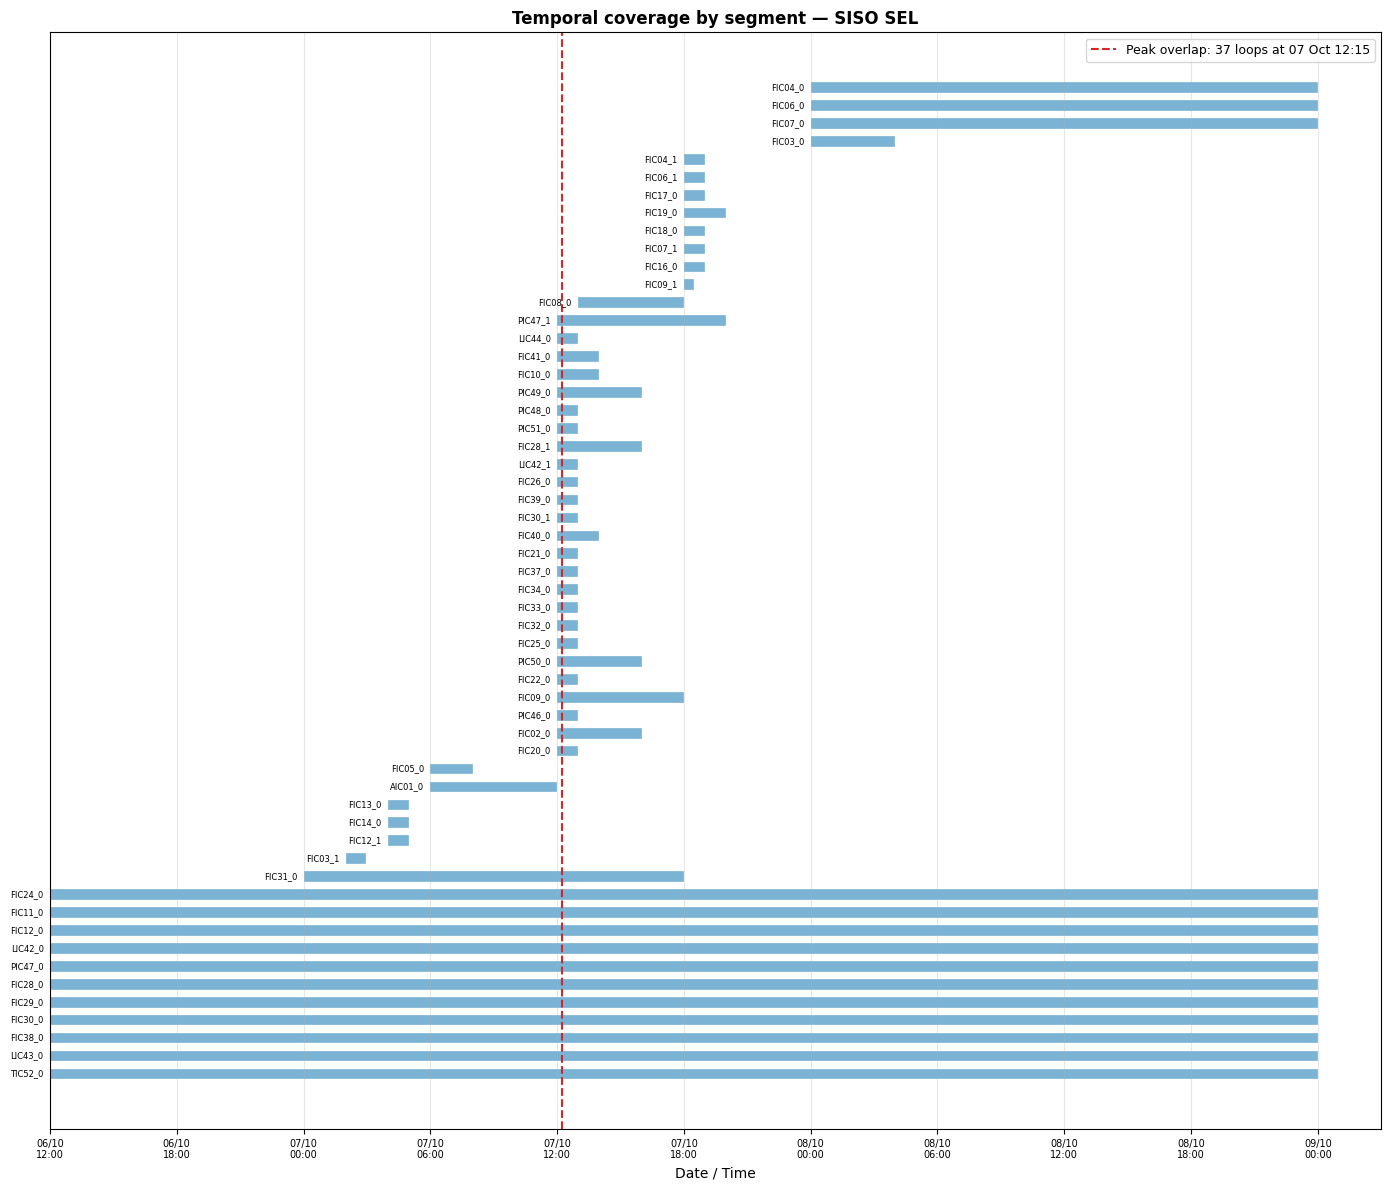

Figure saved → outputs\figures\cpm_temporal_gantt.png


In [5]:
fig, ax = plt.subplots(figsize=(14, 12))

time_df_sorted = time_df.sort_values("t_start").reset_index(drop=True)
t_min = time_df_sorted["t_start"].min()

for i, row in time_df_sorted.iterrows():
    ax.barh(i,
            (row["t_end"] - row["t_start"]).total_seconds() / 3600,
            left=(row["t_start"] - t_min).total_seconds() / 3600,
            height=0.6, color="#4393c3", alpha=0.7, edgecolor="white", linewidth=0.3)
    ax.text((row["t_start"] - t_min).total_seconds() / 3600 - 0.3,
            i, row["segment"], fontsize=6, va="center", ha="right")

hours_grid = pd.date_range(t_min, time_df_sorted["t_end"].max(), freq="15min")
coverage   = []
for t in hours_grid:
    active = time_df_sorted[
        (time_df_sorted["t_start"] <= t) & (time_df_sorted["t_end"] >= t)]
    coverage.append({"t": t, "n_active": len(active),
                     "loops": active["loop_tag"].tolist()})
cov_df = pd.DataFrame(coverage)
best_t = cov_df.loc[cov_df["n_active"].idxmax(), "t"]
best_n = cov_df["n_active"].max()

t_offset = (best_t - t_min).total_seconds() / 3600
ax.axvline(t_offset, color="#d62728", lw=1.5, ls="--",
           label=f"Peak overlap: {best_n} loops at {best_t.strftime('%d %b %H:%M')}")

xticks_h  = list(range(0, 66, 6))
xlabels   = [(t_min + pd.Timedelta(hours=h)).strftime("%d/%m\n%H:%M")
             for h in xticks_h]
ax.set_xticks(xticks_h); ax.set_xticklabels(xlabels, fontsize=7)
ax.set_yticks([]); ax.set_xlabel("Date / Time", fontsize=10)
ax.set_title("Temporal coverage by segment — SISO SEL",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9); ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
out = FIG_DIR / "cpm_temporal_gantt.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved → {out}")


## 4. Loop Selection

### Rationale

For a rigorous CPM analysis, loops must be **contemporaneous** — their data must
cover the same calendar period so that KPIs reflect the same plant conditions.
Comparing a KPI from loop A (measured on Monday morning) with one from loop B
(measured on Wednesday evening) is not meaningful: the plant operating point,
feed conditions and utility loads may differ.

The **11 loops with ≥ 59 h of continuous data** (6–8 Oct 2017) satisfy this requirement.
They share a common 56-hour window, enabling:
- Direct KPI comparison across loops
- Temporal monitoring via non-overlapping 8 h windows (7 windows per loop)
- Cross-correlation analysis for multi-loop interaction (future work)

All other loops in SAMP/SEL have fragments of 0.5–6 h from different time windows
and are therefore excluded from this analysis. They remain valid for single-loop
point-in-time KPI estimation but not for temporal or comparative studies.


In [6]:
loops_60h = (
    time_df[time_df["dur_h"] >= 59]
    .groupby("loop_tag")["dur_h"].max()
    .sort_values(ascending=False)
)

print(f"Loops with >= 59 h in SEL: {len(loops_60h)}")
display(loops_60h.to_frame("dur_h").T)

print("\nSignal inventory in SEL:")
for tag in sorted(loops_60h.index):
    seg = f"{tag}_0"
    with pd.HDFStore(FILES["SEL"], mode="r") as store:
        sigs = [k.split("/")[-1] for k in store.keys()
                if k.startswith(f"/{seg}/")]
    samples = {}
    for sig in sigs:
        with pd.HDFStore(FILES["SEL"], mode="r") as store:
            df = store[f"/{seg}/{sig}"]
        samples[sig] = len(df)
    print(f"  {tag:8s}  signals={sorted(sigs)}  samples={samples}")


Loops with >= 59 h in SEL: 11


loop_tag,FIC11,FIC12,FIC24,FIC28,FIC29,FIC30,FIC38,LIC42,LIC43,PIC47,TIC52
dur_h,59.9990,59.9990,59.9990,59.9990,59.9990,59.9990,59.9990,59.9990,59.9990,59.9990,59.9990



Signal inventory in SEL:
  FIC11     signals=['MV', 'OP', 'PV', 'SP']  samples={'MV': 52023, 'OP': 84688, 'PV': 84500, 'SP': 84679}
  FIC12     signals=['MV', 'OP', 'PV', 'SP']  samples={'MV': 42914, 'OP': 84688, 'PV': 83700, 'SP': 35839}
  FIC24     signals=['MV', 'OP', 'PV', 'SP']  samples={'MV': 42303, 'OP': 84704, 'PV': 84507, 'SP': 84064}
  FIC28     signals=['MV', 'OP', 'PV', 'SP']  samples={'MV': 43482, 'OP': 84685, 'PV': 84729, 'SP': 84675}
  FIC29     signals=['MV', 'OP', 'PV', 'SP']  samples={'MV': 45048, 'OP': 84721, 'PV': 84027, 'SP': 84718}
  FIC30     signals=['MV', 'OP', 'PV', 'SP']  samples={'MV': 56880, 'OP': 84666, 'PV': 84704, 'SP': 84731}
  FIC38     signals=['MV', 'OP', 'PV', 'SP']  samples={'MV': 41116, 'OP': 80164, 'PV': 84447, 'SP': 80158}
  LIC42     signals=['MV', 'OP', 'PV', 'SP']  samples={'MV': 84508, 'OP': 84677, 'PV': 84647, 'SP': 2}
  LIC43     signals=['MV', 'OP', 'PV', 'SP']  samples={'MV': 84688, 'OP': 84695, 'PV': 81884, 'SP': 81895}
  PIC47     sig

## 5. Signal Normalisation Audit

The GIMSCOP dataset uses normalised values in the range **[−0.5, 0.5]** for all signals.
However, SP may be stored in engineering units for some loops if the historian
configuration did not apply the same normalisation as PV/OP/MV.

**Consequences of inconsistent SP scaling:**
- Error-based KPIs (Bias, MAE, IAE_norm) compare PV in [−0.5, 0.5] with SP
  in engineering units → meaningless error values
- TV and oscillation KPIs (which use PV and OP only) remain valid regardless

We check the observed min/max for all four signals across the 11 selected loops.


In [7]:
TAGS_11 = sorted(loops_60h.index)

rows_norm = []
for tag in TAGS_11:
    seg = f"{tag}_0"
    for sig in ["PV", "OP", "SP", "MV"]:
        with pd.HDFStore(FILES["SEL"], mode="r") as store:
            df = store[f"/{seg}/{sig}"]
        s = df["Values"].dropna()
        rows_norm.append({"loop": tag, "signal": sig,
                          "min": round(s.min(), 4), "max": round(s.max(), 4),
                          "range": round(s.max() - s.min(), 4),
                          "n_unique": s.nunique()})

norm_df = pd.DataFrame(rows_norm)

print("Signal range summary (expected: PV/OP/MV in [-0.5, 0.5]):")
display(
    norm_df.pivot_table(index="loop", columns="signal",
                        values=["min", "max", "range"], aggfunc="first").round(4)
)

sp_df = norm_df[norm_df["signal"] == "SP"].copy()
sp_anomalies = sp_df[(sp_df["min"] < -0.5) | (sp_df["max"] > 0.5)]
print(f"\nSP out-of-range loops: {sp_anomalies['loop'].tolist()}")


Signal range summary (expected: PV/OP/MV in [-0.5, 0.5]):


max                           min                          range  \
signal     MV     OP     PV      SP      MV      OP      PV      SP     MV   
loop                                                                         
FIC11  0.5000 0.5000 0.5000  0.4269 -0.5000 -0.5000 -0.5000 -0.4273 1.0000   
FIC12  0.5000 0.5000 0.5000  0.2420 -0.5000 -0.5000 -0.5000 -0.4312 1.0000   
FIC24  0.5000 0.5000 0.5000  0.4581 -0.5000 -0.5000 -0.5000 -0.4911 1.0000   
FIC28  0.5000 0.5000 0.5000  0.4785 -0.5000 -0.5000 -0.5000 -0.4749 1.0000   
FIC29  0.5000 0.5000 0.5000  0.9356 -0.5000 -0.5000 -0.5000  0.3290 1.0000   
FIC30  0.5000 0.5000 0.5000  0.4589 -0.5000 -0.5000 -0.5000 -0.4273 1.0000   
FIC38  0.5000 0.5000 0.5000 -2.0117 -0.5000 -0.5000 -0.5000 -2.4439 1.0000   
LIC42  0.5000 0.5000 0.5000 -0.0946 -0.5000 -0.5000 -0.5000 -0.2427 1.0000   
LIC43  0.5000 0.5000 0.5000  0.5000 -0.5000 -0.5000 -0.5000 -0.5000 1.0000   
PIC47  0.5000 0.5000 0.5000 -0.0653 -0.5000 -0.5000 -0.5000 -0.2063 1.0000   
TIC52  0.5000 0.5000 0.5000  0.0243 -0.5000 -0.5000 -0.5000 -0.0318 1.0000   

                             
signal     OP     PV     SP  
loop                         
FIC11  1.0000 1.0000 0.8542  
FIC12  1.0000 1.0000 0.6732  
FIC24  1.0000 1.0000 0.9492  
FIC28  1.0000 1.0000 0.9534  
FIC29  1.0000 1.0000 0.6066  
FIC30  1.0000 1.0000 0.8862  
FIC38  1.0000 1.0000 0.4321  
LIC42  1.0000 1.0000 0.1481  
LIC43  1.0000 1.0000 1.0000  
PIC47  1.0000 1.0000 0.1411  
TIC52  1.0000 1.0000 0.0561


SP out-of-range loops: ['FIC29', 'FIC38']


## 6. SP Rescaling for Anomalous Loops

For loops where SP is not normalised, we apply **min-max rescaling** to [−0.5, 0.5]
using the observed SP range over the full 60-hour record.

**Validity:** The rescaled SP is plotted against PV to verify that both signals
are on the same physical scale and track each other coherently. If PV and SP
move together after rescaling (as expected for a well-controlled loop), the
rescaling is valid.

**Limitation:** This correction is suitable for qualitative trend analysis.
The absolute magnitude of error-based KPIs for these loops represents a fraction
of the observed SP range, not of the original engineering range. They are
internally consistent but not directly comparable with loops whose SP was
correctly normalised at source. These loops are flagged as `sp_rescaled = True`
in the results table.


Loops requiring SP rescaling: ['FIC29', 'FIC38']


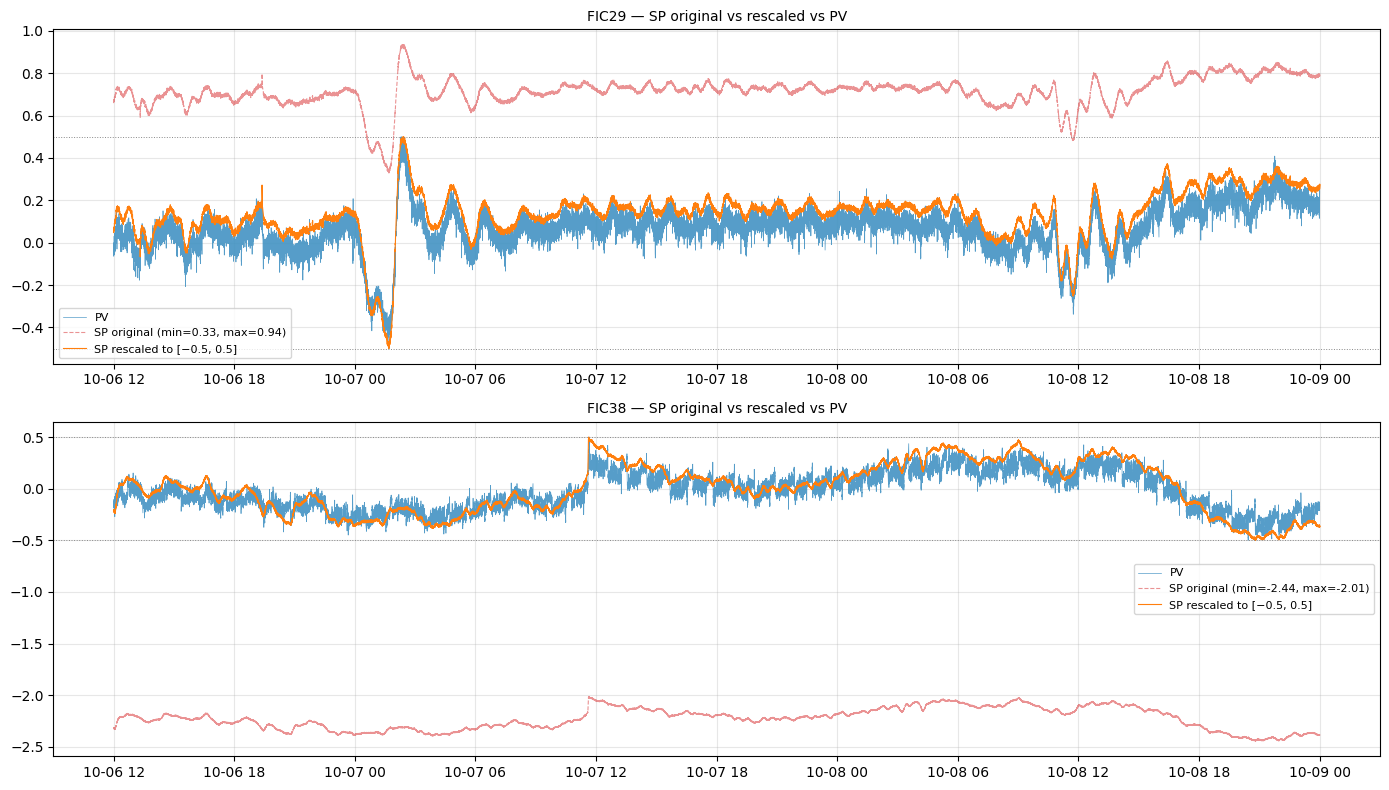

Figure saved → outputs\figures\cpm_sp_rescaling.png


In [8]:
SP_RESCALE_TAGS = set(sp_anomalies["loop"].tolist())
print(f"Loops requiring SP rescaling: {sorted(SP_RESCALE_TAGS)}")

fig, axes = plt.subplots(len(SP_RESCALE_TAGS), 1,
                         figsize=(14, 4 * len(SP_RESCALE_TAGS)))
if len(SP_RESCALE_TAGS) == 1:
    axes = [axes]

for ax, tag in zip(axes, sorted(SP_RESCALE_TAGS)):
    seg = f"{tag}_0"
    with pd.HDFStore(FILES["SEL"], mode="r") as store:
        pv_raw = store[f"/{seg}/PV"]["Values"]
        sp_raw = store[f"/{seg}/SP"]["Values"]

    sp_rescaled = (sp_raw - sp_raw.min()) / (sp_raw.max() - sp_raw.min()) - 0.5

    ax.plot(pv_raw.index, pv_raw.values,
            lw=0.5, color="#4393c3", label="PV", alpha=0.9)
    ax.plot(sp_raw.index, sp_raw.values,
            lw=0.8, ls="--", color="#d62728",
            label=f"SP original (min={sp_raw.min():.2f}, max={sp_raw.max():.2f})",
            alpha=0.5)
    ax.plot(sp_rescaled.index, sp_rescaled.values,
            lw=0.8, color="#ff7f0e", label="SP rescaled to [−0.5, 0.5]")
    ax.axhline( 0.5, color="#888", lw=0.7, ls=":")
    ax.axhline(-0.5, color="#888", lw=0.7, ls=":")
    ax.set_title(f"{tag} — SP original vs rescaled vs PV", fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
out = FIG_DIR / "cpm_sp_rescaling.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved → {out}")


## 7. Data Loading and Resampling Pipeline

### 7.1 Signal alignment

In SEL (as in RAW), each signal (PV, OP, SP, MV) has its own independent timestamp
index because each is logged separately by the historian. To compute KPIs, all signals
must be aligned on a common time axis.

**Approach:** outer join on the union of all timestamp indices, then:
- **PV, MV**: linear time interpolation (continuous process signals)
- **SP, OP**: forward-fill followed by backward-fill (step-hold signals logged on change)

### 7.2 Resampling to regular grid

After alignment, the combined DataFrame is resampled to a perfectly regular grid
at Δt = 2.059 s. The sample index is converted to sequential integers (0, 1, 2, ...)
for compatibility with the KPI computation functions.


In [9]:
def load_sel_loop(tag: str) -> pd.DataFrame:
    """
    Load all 4 signals for a loop from SEL (_0 segment),
    align on a common timestamp index via outer join,
    apply forward/backward-fill for step-hold signals,
    and rescale SP if the loop is in SP_RESCALE_TAGS.

    Returns a DataFrame with datetime index and columns PV, OP, SP, MV.
    Attribute 'sp_rescaled' flags whether SP was rescaled.
    """
    seg     = f"{tag}_0"
    signals = {}
    for sig in ["PV", "OP", "SP", "MV"]:
        with pd.HDFStore(FILES["SEL"], mode="r") as store:
            df = store[f"/{seg}/{sig}"]
        s = df["Values"].rename(sig)
        s = s[~s.index.duplicated(keep="last")]
        signals[sig] = s

    combined = pd.concat(signals.values(), axis=1, join="outer").sort_index()
    combined["SP"] = combined["SP"].ffill().bfill()
    combined["OP"] = combined["OP"].ffill().bfill()

    if tag in SP_RESCALE_TAGS:
        sp = combined["SP"].dropna()
        combined["SP"] = (combined["SP"] - sp.min()) / (sp.max() - sp.min()) - 0.5

    combined.attrs["sp_rescaled"] = tag in SP_RESCALE_TAGS
    return combined


def resample_to_grid(df: pd.DataFrame,
                     dt_seconds: float = DT_SECONDS) -> pd.DataFrame:
    """
    Resample a datetime-indexed DataFrame to a regular grid at dt_seconds interval.
    PV, MV: linear time interpolation.
    SP, OP: forward-fill + backward-fill (step-hold).
    Returns integer sample index (0, 1, 2, ...) compatible with compute_kpis().
    """
    t_start = df.index.min().ceil(f"{int(dt_seconds * 1000)}ms")
    t_end   = df.index.max()
    grid    = pd.date_range(t_start, t_end, freq=f"{dt_seconds}s")

    df_ext = df.reindex(df.index.union(grid)).sort_index()

    for col in ["PV", "MV"]:
        if col in df_ext.columns:
            df_ext[col] = df_ext[col].interpolate(method="time").ffill().bfill()
    for col in ["SP", "OP"]:
        if col in df_ext.columns:
            df_ext[col] = df_ext[col].ffill().bfill()

    df_grid = df_ext.reindex(grid).copy()
    df_grid.index = np.arange(len(df_grid), dtype=float)
    df_grid.index.name = "sample"
    df_grid.attrs = df.attrs
    return df_grid


### 7.3 Pipeline validation — all 11 loops

In [10]:
print("Post-resample NaN check (all must be 0):")
ok = True
for tag in TAGS_11:
    df = resample_to_grid(load_sel_loop(tag))
    nans = df[["PV","OP","SP"]].isna().sum().to_dict()
    flag = "✓" if all(v == 0 for v in nans.values()) else "✗"
    print(f"  {flag} {tag:8s}  samples={len(df):,}  "
          f"dur={len(df)*DT_SECONDS/3600:.1f}h  NaN={nans}  "
          f"sp_rescaled={df.attrs.get('sp_rescaled', False)}")
    if any(v > 0 for v in nans.values()):
        ok = False
print(f"\nAll loops clean: {ok}")


Post-resample NaN check (all must be 0):
  ✓ FIC11     samples=104,903  dur=60.0h  NaN={'PV': 0, 'OP': 0, 'SP': 0}  sp_rescaled=False
  ✓ FIC12     samples=104,903  dur=60.0h  NaN={'PV': 0, 'OP': 0, 'SP': 0}  sp_rescaled=False
  ✓ FIC24     samples=104,904  dur=60.0h  NaN={'PV': 0, 'OP': 0, 'SP': 0}  sp_rescaled=False
  ✓ FIC28     samples=104,905  dur=60.0h  NaN={'PV': 0, 'OP': 0, 'SP': 0}  sp_rescaled=False
  ✓ FIC29     samples=104,904  dur=60.0h  NaN={'PV': 0, 'OP': 0, 'SP': 0}  sp_rescaled=True
  ✓ FIC30     samples=104,905  dur=60.0h  NaN={'PV': 0, 'OP': 0, 'SP': 0}  sp_rescaled=False
  ✓ FIC38     samples=104,904  dur=60.0h  NaN={'PV': 0, 'OP': 0, 'SP': 0}  sp_rescaled=True
  ✓ LIC42     samples=104,905  dur=60.0h  NaN={'PV': 0, 'OP': 0, 'SP': 0}  sp_rescaled=False
  ✓ LIC43     samples=104,905  dur=60.0h  NaN={'PV': 0, 'OP': 0, 'SP': 0}  sp_rescaled=False
  ✓ PIC47     samples=104,905  dur=60.0h  NaN={'PV': 0, 'OP': 0, 'SP': 0}  sp_rescaled=False
  ✓ TIC52     samples=104,904  

## 8. Window Definition

### Rationale for 8-hour non-overlapping windows

**Window length (8 h):**
- One industrial work shift — a natural unit for plant operations review
- 13 987 samples at 2.059 s/sample → sufficient spectral resolution for periods up to ~4 h
- For the slowest expected oscillation (~45 min for FIC12), provides ~10 complete cycles
  per window, satisfying the minimum cycle requirement for reliable KPI estimation

**Non-overlapping windows:**
- Each window represents an independent observation period
- Avoids artificially inflating statistical significance
- Directly comparable to shift-based reporting in industrial DCS systems
- 7 complete windows from 60 h of data (last ~4 h discarded)


In [11]:
WINDOW_H = 8
WINDOW_N = int(WINDOW_H * 3600 / DT_SECONDS)

print(f"Window parameters:")
print(f"  Duration    : {WINDOW_H} h")
print(f"  Samples     : {WINDOW_N:,}")
print(f"  Windows/loop: {int(60*3600/DT_SECONDS) // WINDOW_N}")
print(f"  Overlap     : none")
print()

for tag in TAGS_11:
    df = resample_to_grid(load_sel_loop(tag))
    n_wins = len(df) // WINDOW_N
    discarded = len(df) - n_wins * WINDOW_N
    print(f"  {tag:8s}  {len(df):,} samples → {n_wins} windows  "
          f"({discarded:,} samples discarded)")


Window parameters:
  Duration    : 8 h
  Samples     : 13,987
  Windows/loop: 7
  Overlap     : none

  FIC11     104,903 samples → 7 windows  (6,994 samples discarded)
  FIC12     104,903 samples → 7 windows  (6,994 samples discarded)
  FIC24     104,904 samples → 7 windows  (6,995 samples discarded)
  FIC28     104,905 samples → 7 windows  (6,996 samples discarded)
  FIC29     104,904 samples → 7 windows  (6,995 samples discarded)
  FIC30     104,905 samples → 7 windows  (6,996 samples discarded)
  FIC38     104,904 samples → 7 windows  (6,995 samples discarded)
  LIC42     104,905 samples → 7 windows  (6,996 samples discarded)
  LIC43     104,905 samples → 7 windows  (6,996 samples discarded)
  PIC47     104,905 samples → 7 windows  (6,996 samples discarded)
  TIC52     104,904 samples → 7 windows  (6,995 samples discarded)


## 9. CPM KPI Reference Guide

This section documents each KPI computed by `compute_kpis()`, its physical
interpretation, and the diagnostic thresholds used in this analysis.

---

### Oscillation KPIs

#### OI_zc — Oscillation Index (zero-crossing rate)
**Formula:** number of sign changes of (PV − mean(PV)) divided by (N − 1)
**Range:** [0, 1]
**Threshold:** 0.30
**Interpretation:** OI_zc measures how frequently the centred PV signal crosses
its mean value. For a sinusoidal signal with period T sampled at interval Δt:
OI_zc ≈ 2·Δt/T. At the sampling rate of this dataset (Δt = 2.059 s),
OI_zc = 0.30 corresponds to an oscillation period of approximately 14 s.
For slow but genuine process oscillations (T > 30 min), OI_zc will typically
be very small (< 0.01) even when the oscillation is real and energetic.
OI_zc is therefore most useful for detecting rapid cycling, noisy measurement
response or high-frequency activity, and must always be combined with OI_reg
and P_osc for a complete oscillation diagnosis.
**Limitations:** May remain low for slow regular oscillations. High values can
indicate measurement noise rather than process oscillation.
**Reference:** Hägglund (1995)

---

#### OI_reg — Oscillation Regularity Index
**Formula:** T̄ / (3 · σ_T), where T̄ and σ_T are the mean and standard deviation
of the full-period intervals estimated from the ACF zero crossings of a
low-pass filtered signal
**Range:** [0, ∞); capped at 20 for visualisation (raw value preserved as oi_reg_raw)
**Threshold:** 1.0
**Interpretation:** Ratio of mean period to three times its standard deviation.
OI_reg > 1 means the oscillation has a well-defined, consistent period — a
prerequisite for diagnosing stiction or tuning-induced limit cycles.
OI_reg = NaN indicates that the spectral peak period is too short for the
adaptive LP filter to isolate a meaningful ACF (noise-like signal).
**Diagnostic value in combination with OI_zc:**
- High OI_zc + High OI_reg → genuine, regular, sustained oscillation
- High OI_zc + Low OI_reg → irregular or intermittent oscillation (noise, disturbances)
- Low OI_zc + High OI_reg → regular oscillation below the ZC threshold — OI_reg
  is the more sensitive detector in this case
**Reference:** Thornhill, Huang & Zhang (2003); Jelali (2013)

---

#### oscillation_period_s — Dominant Oscillation Period
**Formula:** 1 / f_peak, where f_peak is the frequency of the FFT power spectrum
peak, excluding DC and periods longer than N/4 samples
**Unit:** seconds
**Interpretation:** The period at which the signal concentrates most of its
oscillatory energy. Diagnostic significance:
- T < 30 s at this sampling rate → likely measurement noise
- T = 2–10 × process time constant → consistent with tuning-induced oscillation
- T > 30 min → slow process dynamics or inter-loop interaction
- Very similar T across multiple loops → common-cause disturbance or cascade propagation

---

#### period_std_s — Period Standard Deviation
**Formula:** std(ACF zero-crossing intervals) · Δt
**Unit:** seconds
**Interpretation:** Variability of the oscillation period across the analysis window.
Low σ_T relative to T̄ (i.e., high OI_reg) indicates a clock-like, mechanistic
oscillation source (stiction, tuning limit cycle). High σ_T indicates an irregular,
disturbance-driven signal.

---

#### p_osc — Spectral Power Fraction
**Formula:** Power in the ±1 octave band around f_dom / total signal power (excl. DC)
**Unit:** %
**Interpretation:** Fraction of total signal variance concentrated at the dominant
oscillation frequency. Complements OI_zc and OI_reg:
- P_osc < 10%: oscillation is weak relative to broadband noise or drift
- P_osc 10–40%: moderate oscillation, mixed with noise
- P_osc > 40%: dominant, energetic oscillation
**Reference:** Thornhill, Huang & Zhang (2003)

---

### Valve Activity KPIs

#### tv_op_norm — Normalised Total Variation of OP
**Formula:** Σ|ΔOP| / (range(OP) · N)
**Range:** [0, ∞), typically [0, 0.5] in practice
**Threshold:** 0.08 (indicative; application-dependent)
**Interpretation:** Average absolute change in controller output per sample,
normalised by the operating range. High TV_norm indicates aggressive control
action, which accelerates valve wear and may indicate excessive integral gain
or response to measurement noise. For this dataset, where OP is normalised to
[−0.5, 0.5] (range ≈ 1.0), TV_norm = 0.08 means the controller output moves
on average 8% of its full range every 2.059 s — a practically meaningful
threshold for excessive activity.

---

#### tv_op_abs — Absolute Total Variation of OP
**Formula:** Σ|ΔOP|
**Unit:** normalised units (same as OP)
**Interpretation:** Total distance travelled by the controller output over the
analysis window. Useful for estimating relative valve wear. Not directly
comparable across loops with different operating ranges — use tv_op_norm
for cross-loop comparison.

---

#### op_direction_change_rate (DCR) — Direction Change Rate
**Formula:** number of OP sign reversals / N
**Range:** [0, 1]
**Interpretation:** Fraction of samples at which the controller output reverses
direction. Combined with tv_op_norm in the TV–DCR diagnostic plane:
- High TV + High DCR → aggressive tuning (many large reversals)
- High TV + Low DCR → integrator windup or ramp-like behaviour
- Low TV + High DCR → noisy signal driving many small reversals
- Low TV + Low DCR → normal or sluggish control

---

#### op_sat_frac — Empirical OP Bound Fraction
**Formula:** fraction of samples where OP ≤ lower 0.5th percentile + tolerance
or OP ≥ upper 99.5th percentile − tolerance
**Range:** [0, 1]
**Interpretation:** Proportion of time the controller output spends near its
observed extremes. High values may indicate constrained control behaviour or
limited valve authority.
**Note:** This metric uses empirical OP quantiles as proxies for the physical
controller output limits, which are not available in this dataset. op_sat_frac > 0
does not confirm true actuator saturation — it indicates that OP spends time
near its observed extremes. Interpret as a screening indicator only.

---

### Tracking Error KPIs
*(computed only when SP coverage ≥ 5%)*

#### mae — Mean Absolute Error
**Formula:** mean|PV − SP|
**Unit:** normalised units
**Interpretation:** Average absolute deviation of the process variable from the
setpoint. Directly interpretable as a fraction of the full instrument range.

---

#### rmse — Root Mean Square Error
**Formula:** √mean((PV − SP)²)
**Unit:** normalised units
**Interpretation:** Similar to MAE but penalises large deviations more heavily.
RMSE > MAE indicates the presence of occasional large excursions from SP.

---

#### bias — Mean Signed Error
**Formula:** mean(PV − SP)
**Unit:** normalised units
**Interpretation:** Systematic offset between PV and SP. A persistent non-zero
bias indicates that the loop is not achieving the setpoint on average. Possible
causes: instrument calibration drift, incorrect SP scaling, controller in manual
or cascade mode, or an unachievable setpoint given the process capacity.
A bias close to zero does not exclude oscillation.

---

#### iae_norm — Normalised Integrated Absolute Error
**Formula:** MAE / σ_PV
**Range:** [0, ∞)
**Threshold:** 2.0 (indicative)
**Interpretation:** MAE normalised by the standard deviation of PV. Values < 1
indicate good tracking relative to process variability. Values > 2 indicate
that the average error dominates over the process variance.

---

### Notes on SP Rescaling

For loops flagged as `sp_rescaled = True` (FIC29, FIC38), the SP signal was
stored in engineering units at the historian source while PV, OP and MV were
normalised to [−0.5, 0.5]. A min-max rescaling was applied to SP using the
observed range over the 60-hour record before computing any error-based KPIs.

All oscillation and valve activity KPIs are **not affected** by SP scaling.
Error-based KPIs for these loops are internally consistent but represent
deviations as fractions of the observed SP range, not of the original
engineering range. Suitable for qualitative trend analysis only.

---

### Positioner Tracking KPIs

These KPIs compare the controller output (OP) with the manipulated variable (MV)
to screen for possible inconsistencies between the controller command and the
valve-related feedback signal. They are computed only when MV is available with
sufficient coverage (≥ 100 aligned samples after resampling).

**Important:** These metrics are screening indicators, not definitive fault diagnoses.
Confirming root causes such as valve stiction, positioner miscalibration or
actuator backlash requires additional plant context: valve datasheets, maintenance
records, phase-plane analysis and process topology information.

#### op_mv_bias — OP−MV Systematic Offset
**Formula:** mean(OP − MV)
**Threshold:** ±0.05 (normalised units)
**Interpretation:** Persistent signed difference between controller command and
valve-related feedback. Values outside ±0.05 may indicate a calibration offset,
a signal-definition mismatch, or a scaling difference between OP and MV.

#### op_mv_mae — OP−MV Mean Absolute Error
**Formula:** mean|OP − MV|
**Interpretation:** Average absolute discrepancy between command and feedback.
Combines both systematic offset and dynamic tracking error.

#### op_mv_corr — OP−MV Correlation
**Formula:** Pearson correlation coefficient between OP and MV time series
**Threshold:** 0.95
**Interpretation:** Dynamic tracking quality. Values below 0.95 indicate that MV
does not faithfully follow OP — possibly consistent with mechanical friction,
backlash, or a slow positioner. Requires plant verification to confirm.

#### tv_mv_op_ratio — TV Ratio MV/OP
**Formula:** TV(MV) / TV(OP)
**Thresholds:** < 0.60 → attenuated MV response · < 0.80 → slightly attenuated · > 3.0 → MV ≠ valve position
**Interpretation:**
- **ratio < 1**: MV travels less than OP commands — consistent with friction or
  mechanical resistance in the actuator. The further below 1, the more attenuated
  the valve response. FIC38 (0.39) and FIC28 (0.56) show the most attenuation.
- **ratio ≈ 1**: commanded and feedback travel match — positioner behaviour consistent.
- **ratio > 1**: MV varies more than OP — possible external process forcing or
  MV measuring a variable other than valve position.
- **ratio >> 3**: MV is likely not the physical valve position but a downstream
  process measurement oscillating independently of the controller.
  LIC42 (12.2) and FIC30 (4.8) fall into this category — positioner diagnostics
  do not apply to these loops.

#### mv_is_valve_position — MV Validity Flag
**Formula:** True if tv_mv_op_ratio < 3.0, False otherwise
**Interpretation:** Screening flag. When False, all positioner KPIs for that loop
should be treated as not applicable. This does not confirm that MV is a valve
position signal when True — it only indicates the ratio is within a plausible range.


## 10. KPI Helper Functions

Three oscillation metrics are computed and reported independently:

- **OI_zc**: fast screening index (Hägglund 1995). Threshold 0.30. No pre-filtering required.
  Most useful for detecting rapid cycling or high-frequency activity. May be low even
  for genuine slow oscillations (see KPI Reference Guide for the period-dependence).
- **OI_reg**: regularity index from ACF zero crossings (Thornhill et al. 2003).
  Uses an adaptive low-pass filter at cutoff = T_osc/4. OI_reg > 1 confirms
  a well-defined, consistent oscillation period. OI_reg = NaN indicates that
  the detected period is too short to be a real process oscillation.
- **P_osc**: spectral power fraction in the ±1 octave band around the dominant frequency.
  Quantifies how much of the signal variance is concentrated at the oscillation frequency.

The combination of all three provides more diagnostic value than any single index.


In [12]:
from scipy.signal import butter, filtfilt

def dominant_spectral_period(signal: np.ndarray, dt: float) -> float:
    """
    Estimate dominant oscillation period from the FFT power spectrum peak.
    Excludes DC and periods longer than N/4 samples.
    """
    n    = len(signal)
    fft  = np.fft.rfft(signal - signal.mean())
    pwr  = np.abs(fft) ** 2
    freq = np.fft.rfftfreq(n, d=dt)

    f_min = 4.0 / (n * dt)
    valid = (freq >= f_min) & (freq > 0)

    if valid.sum() < 2:
        return np.nan
    peak_idx = np.argmax(pwr[valid])
    f_peak   = freq[valid][peak_idx]
    return 1.0 / f_peak if f_peak > 0 else np.nan


def compute_oi_reg(signal: np.ndarray, dt: float,
                   T_osc: float) -> dict:
    """
    Compute OI_reg (regularity index) via ACF of a low-pass filtered signal.
    LP cutoff = T_osc / 4 (adaptive to the dominant period).

    ACF zero crossings of a signal with period T occur at lags T/4, 3T/4, 5T/4...
    Taking every other zero crossing (zc[::2]) gives intervals of exactly T.
    Multiplying by dt converts from samples to seconds.
    OI_reg = T_mean / (3 * T_std) is scale-invariant and correct regardless of T.
    """
    result = {"oi_reg": np.nan, "period_std_s": np.nan}

    if np.isnan(T_osc) or T_osc <= 0:
        return result

    cutoff_hz = 1.0 / (T_osc / 4.0)
    nyq        = 0.5 / dt
    if cutoff_hz >= nyq * 0.95:
        return result   # period too short — signal is noise-like

    try:
        b, a     = butter(2, cutoff_hz / nyq, btype="low")
        filtered = filtfilt(b, a, signal)
    except Exception:
        return result

    acf_len = min(len(filtered) // 2, int(5 * T_osc / dt))
    if acf_len < 4:
        return result

    acf = np.correlate(filtered[:acf_len], filtered[:acf_len], mode="full")
    acf = acf[len(acf) // 2:]
    acf /= (acf[0] + 1e-12)

    signs = np.sign(acf)
    zc    = np.where(np.diff(signs) != 0)[0]
    if len(zc) < 3:
        return result

    # diff(zc[::2]) in sample units already represents full periods T/dt
    # Multiply by dt to convert to seconds — no additional factor of 2 needed
    intervals = np.diff(zc[::2]) * dt
    if len(intervals) < 2:
        return result

    T_mean = intervals.mean()
    T_std  = intervals.std()

    result["period_std_s"] = float(T_std)                              # std of full periods
    result["oi_reg"]       = float(T_mean / (3 * T_std + 1e-12))      # OI_reg unchanged
    return result


def compute_p_osc(signal: np.ndarray, dt: float, T_osc: float,
                  octaves: float = 1.0) -> float:
    """
    Spectral power fraction in the ±1 octave band around the dominant frequency.
    """
    if np.isnan(T_osc) or T_osc <= 0:
        return np.nan

    n    = len(signal)
    fft  = np.fft.rfft(signal - signal.mean())
    pwr  = np.abs(fft) ** 2
    freq = np.fft.rfftfreq(n, d=dt)

    f_dom  = 1.0 / T_osc
    f_low  = f_dom / (2 ** octaves)
    f_high = f_dom * (2 ** octaves)

    band  = (freq >= f_low) & (freq <= f_high) & (freq > 0)
    total = pwr[freq > 0].sum()

    if total < 1e-12:
        return np.nan
    return float(100.0 * pwr[band].sum() / total)


print("KPI helper functions defined")


KPI helper functions defined


## 11. KPI Computation Function

In [13]:
def compute_kpis(tag: str, df: pd.DataFrame) -> dict:
    """
    Compute all CPM KPIs for a single loop segment.

    Parameters
    ----------
    tag : str  Loop identifier.
    df  : pd.DataFrame
        Float sample index (0, 1, 2, ...) and columns PV, OP, SP, MV.
        Real time = sample * DT_SECONDS.

    Returns
    -------
    dict of KPI values. Error-based KPIs only if SP coverage >= 5%.
    """
    result  = {"loop_tag": tag}
    pv      = df["PV"].dropna().astype(float)
    sp_cov  = float(df["SP"].notna().mean()) if "SP" in df.columns else 0.0

    result["pv_mean"]     = float(pv.mean())
    result["pv_std"]      = float(pv.std())
    result["sp_coverage"] = sp_cov

    if len(pv) < 32:
        return result

    # Oscillation signal: error (PV-SP) if SP available, else centred PV
    if sp_cov >= 0.05 and "SP" in df.columns:
        valid      = df["PV"].notna() & df["SP"].notna()
        osc_signal = (df.loc[valid, "PV"] - df.loc[valid, "SP"]).values
    else:
        osc_signal = (pv - pv.mean()).values

    if len(osc_signal) % 2 != 0:
        osc_signal = osc_signal[:-1]

    # ── OI zero-crossing (Hägglund 1995) ────────────────────────────────────
    pv_c  = pv - pv.mean()
    signs = np.sign(pv_c.values)
    signs = signs[signs != 0]
    result["oi_zc"] = (
        float(np.sum(np.diff(signs) != 0)) / (len(signs) - 1)
        if len(signs) > 1 else np.nan
    )

    # ── Dominant period (spectral peak) ─────────────────────────────────────
    T_osc = dominant_spectral_period(osc_signal, DT_SECONDS)
    result["oscillation_period_s"] = T_osc

    # ── OI_reg (ACF with adaptive LP) ───────────────────────────────────────
    result.update(compute_oi_reg(osc_signal, DT_SECONDS, T_osc))

    # ── P_osc ────────────────────────────────────────────────────────────────
    result["p_osc"] = compute_p_osc(osc_signal, DT_SECONDS, T_osc)

    # ── OP-based KPIs ─────────────────────────────────────────────────────────
    if "OP" in df.columns:
        op       = df["OP"].dropna().astype(float)
        op_range = float(op.max() - op.min())
        tv_abs   = float(op.diff().abs().sum())
        result["tv_op_abs"]  = tv_abs
        result["tv_op_norm"] = (tv_abs / (op_range * len(op))
                                if op_range > 1e-9 else np.nan)

        lo  = float(op.quantile(0.005))
        hi  = float(op.quantile(0.995))
        tol = max((hi - lo) * 0.01, 1e-6)
        result["op_sat_frac"] = float(((op <= lo + tol) | (op >= hi - tol)).mean())

        op_diff  = np.diff(op.values)
        op_signs = np.sign(op_diff)
        op_signs = op_signs[op_signs != 0]
        if len(op_signs) > 1:
            n_rev = int(np.sum(np.diff(op_signs) != 0))
            result["op_direction_changes"]     = n_rev
            result["op_direction_change_rate"] = n_rev / len(op)
        else:
            result["op_direction_changes"]     = 0
            result["op_direction_change_rate"] = 0.0

    # ── Error-based KPIs ──────────────────────────────────────────────────────
    if sp_cov >= 0.05:
        valid = df["PV"].notna() & df["SP"].notna()
        err   = (df.loc[valid, "PV"] - df.loc[valid, "SP"]).astype(float)
        result["mae"]      = float(err.abs().mean())
        result["rmse"]     = float(np.sqrt((err ** 2).mean()))
        result["bias"]     = float(err.mean())
        result["iae_norm"] = (
            result["mae"] / result["pv_std"]
            if result.get("pv_std", 0) > 1e-9 else np.nan
        )

    # ── SP variability ─────────
    if sp_cov >= 0.05:
        result["sp_std"]  = float(df["SP"].dropna().std())
        result["sp_mean"] = float(df["SP"].dropna().mean())

    # ── Positioner tracking KPIs (requires MV) ───────────────────────────────
    if "MV" in df.columns and "OP" in df.columns:
        op = df["OP"].dropna().astype(float)
        mv = df["MV"].dropna().astype(float)
        aligned = pd.concat([op.rename("OP"), mv.rename("MV")],
                            axis=1).dropna()
        if len(aligned) >= 100:
            diff = aligned["OP"] - aligned["MV"]
            result["op_mv_bias"] = float(diff.mean())
            result["op_mv_mae"]  = float(diff.abs().mean())
            result["op_mv_corr"] = float(aligned["OP"].corr(aligned["MV"]))

            tv_op_mv = float(aligned["OP"].diff().abs().sum())
            tv_mv    = float(aligned["MV"].diff().abs().sum())
            ratio    = tv_mv / tv_op_mv if tv_op_mv > 1e-9 else np.nan
            result["tv_mv_op_ratio"] = ratio

            result["mv_is_valve_position"] = (
                bool(ratio < 3.0) if not np.isnan(ratio) else None
            )

    return result


print("compute_kpis() defined")


compute_kpis() defined


## 12. KPI Computation — 11 Loops × 7 Windows

Each loop is loaded from SEL, resampled to the regular grid, and split into
7 non-overlapping 8-hour windows. KPIs are computed independently for each window.

After computation:
- `oi_reg_raw` preserves the raw OI_reg value (can be very large for near-perfect regularity)
- `oi_reg_plot` clips OI_reg at 20 for visualisation clarity


In [14]:
OI_REG_CAP = 20.0

all_kpis = []

for tag in TAGS_11:
    df_loop     = resample_to_grid(load_sel_loop(tag))
    n_wins      = len(df_loop) // WINDOW_N
    sp_rescaled = df_loop.attrs.get("sp_rescaled", False)

    for w in range(n_wins):
        start  = w * WINDOW_N
        df_win = df_loop.iloc[start:start + WINDOW_N].copy()
        df_win.index = np.arange(len(df_win), dtype=float)
        df_win.index.name = "sample"

        kpis = compute_kpis(tag, df_win)
        kpis["window"]         = w + 1
        kpis["window_start_h"] = round(start * DT_SECONDS / 3600, 1)
        kpis["window_end_h"]   = round((start + WINDOW_N) * DT_SECONDS / 3600, 1)
        kpis["sp_rescaled"]    = sp_rescaled
        all_kpis.append(kpis)

    print(f"  {tag:8s}  {n_wins} windows  sp_rescaled={sp_rescaled}")

kpi_windows = (pd.DataFrame(all_kpis)
               .sort_values(["loop_tag", "window"])
               .reset_index(drop=True))

# OI_reg: preserve raw, cap for plots
kpi_windows["oi_reg_raw"]  = kpi_windows["oi_reg"]
kpi_windows["oi_reg_plot"] = kpi_windows["oi_reg"].clip(upper=OI_REG_CAP)

print(f"\nKPI table: {len(kpi_windows)} rows × {len(kpi_windows.columns)} columns")
print(f"OI_reg  raw max  = {kpi_windows['oi_reg_raw'].max():.2f}")
print(f"OI_reg  plot max = {kpi_windows['oi_reg_plot'].max():.2f}  (capped at {OI_REG_CAP})")
num_cols = [c for c in kpi_windows.columns
            if c not in ("loop_tag","window","sp_rescaled","mv_is_valve_position",
                         "oi_reg_raw","oi_reg_plot")]
display(kpi_windows[num_cols].describe().round(3))


  FIC11     7 windows  sp_rescaled=False
  FIC12     7 windows  sp_rescaled=False
  FIC24     7 windows  sp_rescaled=False
  FIC28     7 windows  sp_rescaled=False
  FIC29     7 windows  sp_rescaled=True
  FIC30     7 windows  sp_rescaled=False
  FIC38     7 windows  sp_rescaled=True
  LIC42     7 windows  sp_rescaled=False
  LIC43     7 windows  sp_rescaled=False
  PIC47     7 windows  sp_rescaled=False
  TIC52     7 windows  sp_rescaled=False

KPI table: 77 rows × 31 columns
OI_reg  raw max  = 55593000000000.01
OI_reg  plot max = 20.00  (capped at 20.0)


,pv_mean,pv_std,sp_coverage,oi_zc,oscillation_period_s,oi_reg,period_std_s,p_osc,tv_op_abs,tv_op_norm,...,bias,iae_norm,sp_std,sp_mean,op_mv_bias,op_mv_mae,op_mv_corr,tv_mv_op_ratio,window_start_h,window_end_h
count,77.0000,77.0000,77.0000,77.0000,77.0000,50.0000,50.0000,77.0000,77.0000,77.0000,...,77.0000,77.0000,77.0000,77.0000,77.0000,77.0000,77.0000,77.0000,77.0000,77.0000
mean,0.0190,0.0940,1.0000,0.0410,2965.7390,1111860000004.8350,322.2770,37.0180,50.6880,0.0080,...,0.0080,0.6530,0.0650,0.0110,0.0030,0.0390,0.9170,2.3050,24.0000,32.0000
std,0.1190,0.0410,0.0000,0.0390,2126.6680,7862037457300.0508,325.7570,21.8200,36.0970,0.0060,...,0.0620,0.5060,0.0580,0.1310,0.0510,0.0430,0.1270,3.3990,16.1050,16.1050
min,-0.3190,0.0300,1.0000,0.0000,56.2440,0.5700,0.0000,3.9080,3.0530,0.0000,...,-0.1040,0.0040,0.0000,-0.3190,-0.1200,0.0000,0.3110,0.3790,0.0000,8.0000
25%,-0.0260,0.0610,1.0000,0.0040,822.7760,0.8750,80.1490,22.3150,22.3000,0.0030,...,-0.0020,0.2920,0.0050,-0.0650,-0.0030,0.0100,0.9080,0.7160,8.0000,16.0000
50%,0.0150,0.0920,1.0000,0.0320,3599.6470,2.7520,237.8080,30.5050,39.8250,0.0060,...,0.0000,0.5380,0.0530,0.0010,0.0010,0.0200,0.9680,0.8970,24.0000,32.0000
75%,0.0910,0.1140,1.0000,0.0630,3599.6470,5.5630,420.9270,52.4340,71.2440,0.0120,...,0.0030,0.8890,0.0940,0.0990,0.0120,0.0470,0.9890,1.6080,40.0000,48.0000
max,0.3830,0.1950,1.0000,0.1840,7199.2940,55593000000000.0078,1380.2270,89.0500,152.2370,0.0250,...,0.2590,2.2670,0.2600,0.3830,0.1700,0.1700,1.0000,13.4390,48.0000,56.0000


## 13. Results & Visualisation

### 13.1 KPI heatmap — temporal evolution

Each cell shows the KPI value for one loop (row) in one 8-hour window (column).
OI_reg is shown using the capped version (oi_reg_plot, max = 20) for readability.

**Reading guide:**
- **OI_zc**: values above the 0.30 threshold indicate high-frequency activity
- **OI_reg**: values > 1.0 confirm a *regular* oscillation with consistent period
- **TV_norm**: high values indicate excessive valve travel
- **Bias**: persistent non-zero bias indicates a tracking error or SP scaling issue
- **IAE_norm**: normalised integrated error; values > 2 indicate poor tracking


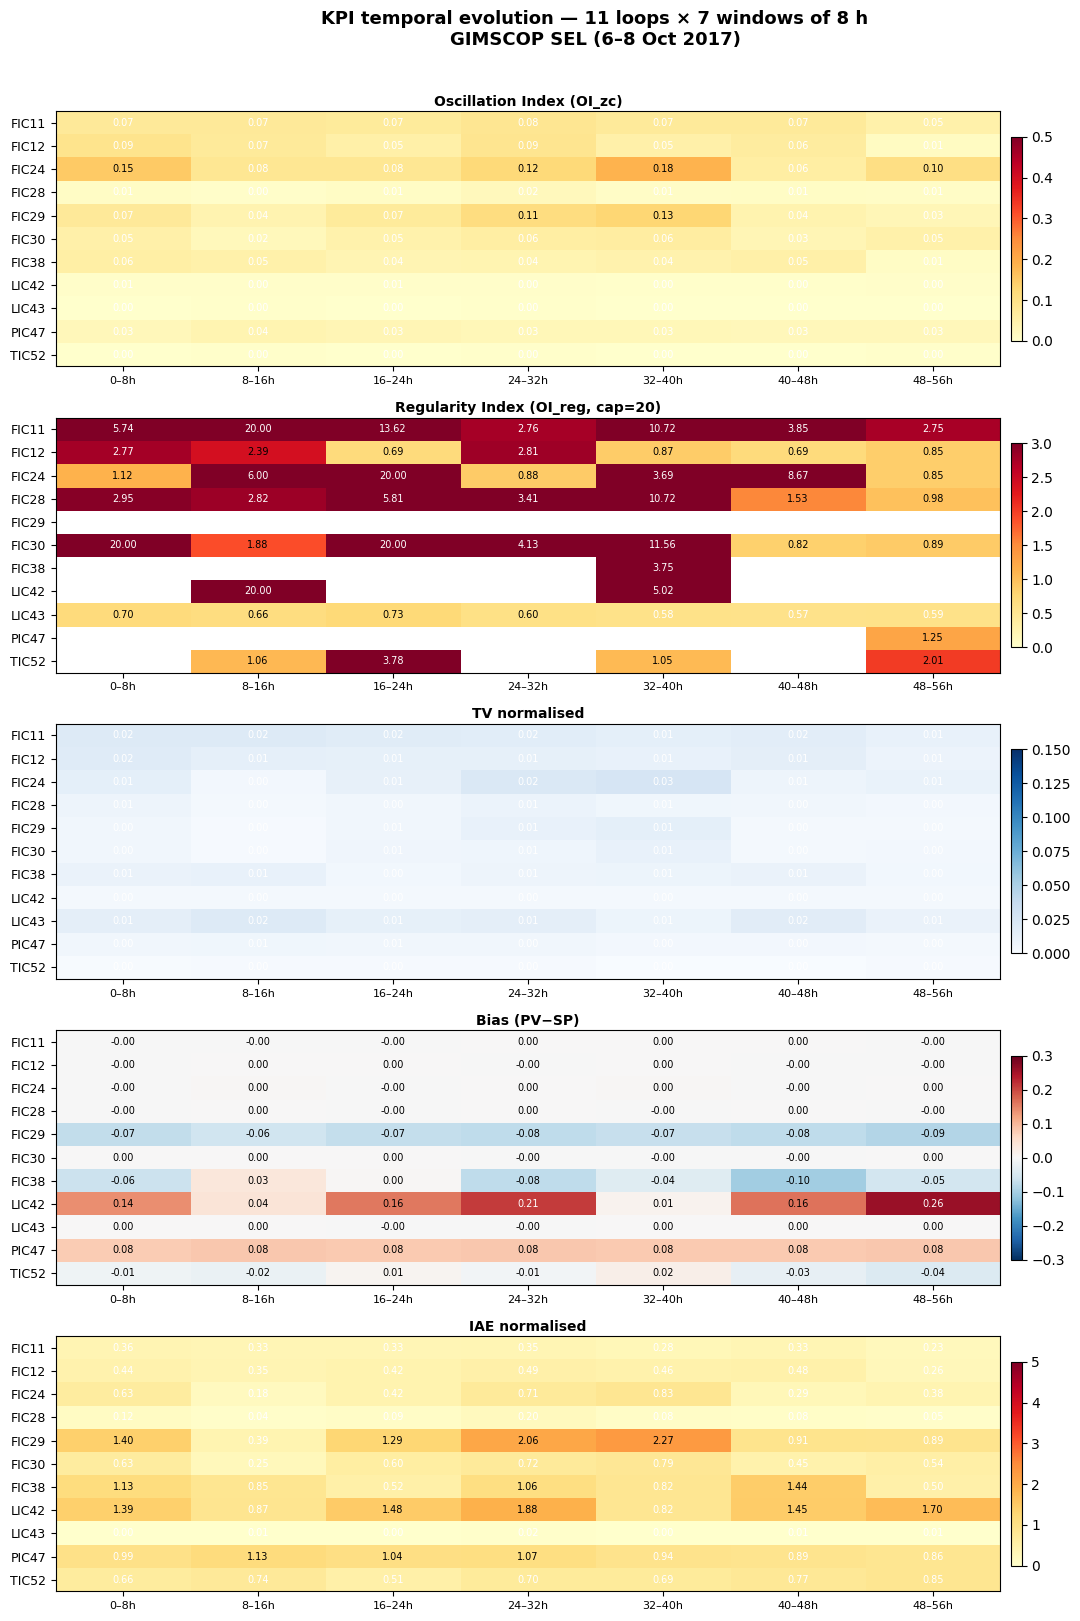

Figure saved → outputs\figures\cpm_kpi_heatmap.png
Note: OI_reg displayed using oi_reg_plot (capped at 20). Raw values in oi_reg_raw column.


In [15]:
KPI_PLOT = {
    "oi_zc":          ("Oscillation Index (OI_zc)",          "YlOrRd", 0,    0.5),
    "oi_reg_plot":    ("Regularity Index (OI_reg, cap=20)",  "YlOrRd", 0,    3.0),
    "tv_op_norm":     ("TV normalised",                       "Blues",  0,    0.15),
    "bias":           ("Bias (PV−SP)",                        "RdBu_r", -0.3, 0.3),
    "iae_norm":       ("IAE normalised",                      "YlOrRd", 0,    5.0),
}

wins_labels = [f"{(w-1)*8}–{w*8}h" for w in range(1, 8)]

fig, axes = plt.subplots(len(KPI_PLOT), 1,
                         figsize=(12, 3.2 * len(KPI_PLOT)))
fig.suptitle("KPI temporal evolution — 11 loops × 7 windows of 8 h\n"
             "GIMSCOP SEL (6–8 Oct 2017)",
             fontsize=13, fontweight="bold", y=1.01)

for ax, (col, (title, cmap, vmin, vmax)) in zip(axes, KPI_PLOT.items()):
    pivot = kpi_windows.pivot(index="loop_tag", columns="window", values=col)
    pivot.columns = wins_labels

    im = ax.imshow(pivot.values, aspect="auto", cmap=cmap,
                   vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, shrink=0.8, pad=0.01)
    ax.set_xticks(range(7)); ax.set_xticklabels(wins_labels, fontsize=8)
    ax.set_yticks(range(len(pivot)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold", pad=4)

    for i in range(len(pivot)):
        for j in range(7):
            val = pivot.iloc[i, j]
            if pd.notna(val):
                txt   = f"{val:.2f}"
                color = ("white"
                         if abs((val - vmin) / (vmax - vmin + 1e-9) - 0.5) > 0.3
                         else "black")
                ax.text(j, i, txt, ha="center", va="center",
                        fontsize=7, color=color)

plt.tight_layout()
out = FIG_DIR / "cpm_kpi_heatmap.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved → {out}")
print("Note: OI_reg displayed using oi_reg_plot (capped at 20). Raw values in oi_reg_raw column.")


### 13.2 KPI bar charts — per loop per window

Grouped bars show the KPI value for each loop across the 7 windows.
The colour gradient from light to dark blue encodes window progression (W1 → W7).
Dashed red lines mark the classification thresholds.
OI_reg uses the capped version (max = 20) for readability.


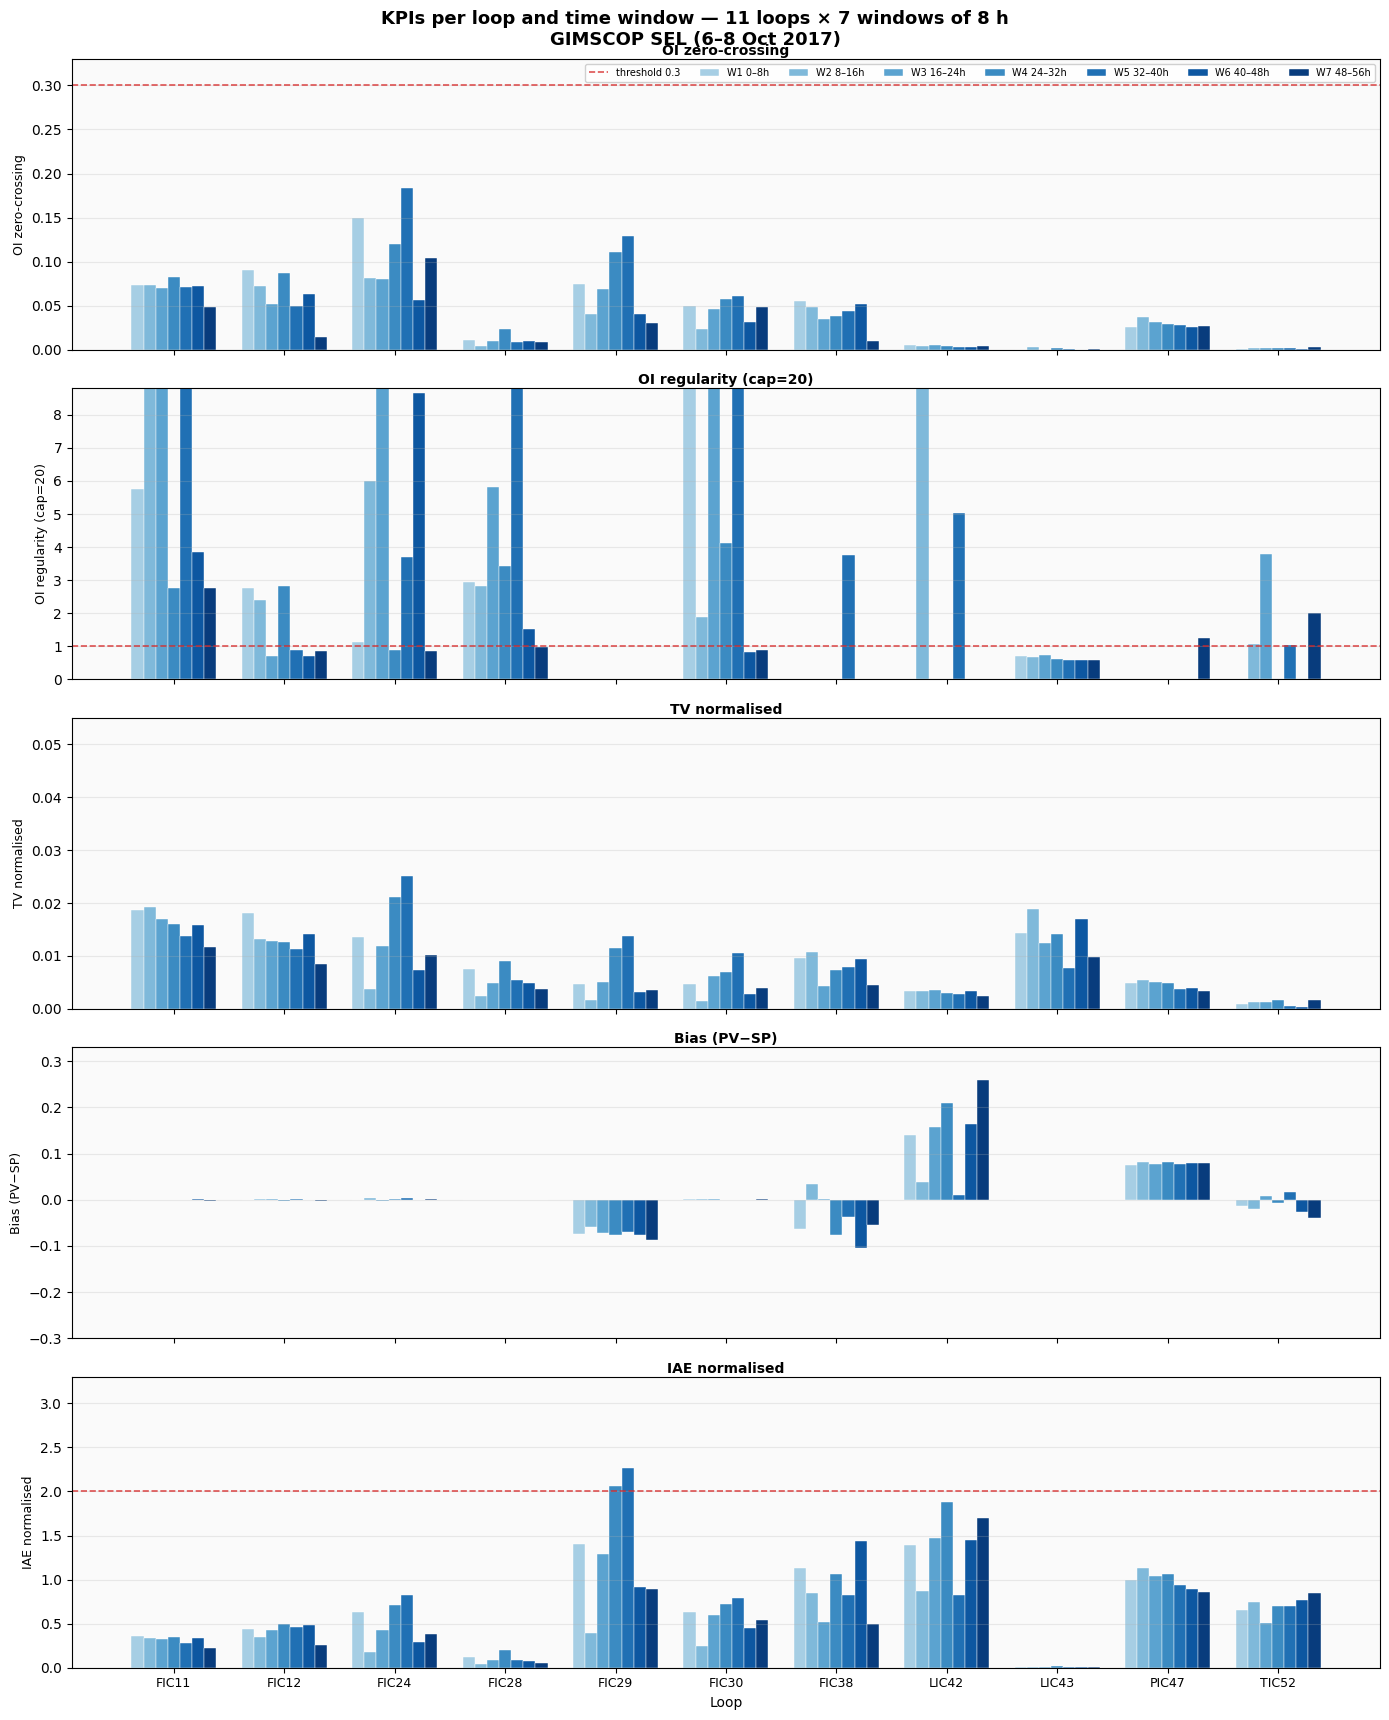

Figure saved → outputs\figures\cpm_kpi_bars.png


In [16]:
KPI_BAR = {
    "oi_zc":          ("OI zero-crossing",       0.30, "YlOrRd", 0.0,  0.30),
    "oi_reg_plot":    ("OI regularity (cap=20)", 1.00, "YlOrRd", 0.0,  8.0),
    "tv_op_norm":     ("TV normalised",           0.08, "Blues",  0.0,  0.05),
    "bias":           ("Bias (PV−SP)",            None, "RdBu_r", -0.3,  0.3),
    "iae_norm":       ("IAE normalised",          2.00, "YlOrRd", 0.0,  3.0),
}

tags_sorted = sorted(kpi_windows["loop_tag"].unique())
n_tags      = len(tags_sorted)
wins        = sorted(kpi_windows["window"].unique())
n_wins      = len(wins)
bar_w       = 0.11
offsets     = np.linspace(-(n_wins-1)/2, (n_wins-1)/2, n_wins) * bar_w
x           = np.arange(n_tags)
win_colors  = plt.cm.Blues(np.linspace(0.35, 0.95, n_wins))

fig, axes = plt.subplots(len(KPI_BAR), 1,
                         figsize=(14, 3.5 * len(KPI_BAR)), sharex=True)
fig.suptitle("KPIs per loop and time window — 11 loops × 7 windows of 8 h\n"
             "GIMSCOP SEL (6–8 Oct 2017)",
             fontsize=13, fontweight="bold")

for ax, (col, (title, threshold, cmap, ymin, ymax)) in zip(axes, KPI_BAR.items()):
    for wi, (w, color) in enumerate(zip(wins, win_colors)):
        vals = []
        for tag in tags_sorted:
            row = kpi_windows[(kpi_windows["loop_tag"] == tag) &
                              (kpi_windows["window"] == w)]
            vals.append(row[col].values[0] if len(row) else np.nan)
        ax.bar(x + offsets[wi], np.array(vals, dtype=float),
               width=bar_w, color=color, edgecolor="white", linewidth=0.3,
               label=f"W{w} {(w-1)*8}–{w*8}h")

    if threshold is not None:
        ax.axhline(threshold, color="#d62728", lw=1.2, ls="--",
                   alpha=0.8, label=f"threshold {threshold}")

    ax.set_xticks(x); ax.set_xticklabels(tags_sorted, fontsize=9)
    ax.set_ylabel(title, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold", pad=3)
    ax.set_ylim(ymin, ymax * 1.1)
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_facecolor("#fafafa")
    if col == "oi_zc":
        ax.legend(ncol=8, fontsize=7, loc="upper right",
                  framealpha=0.9, edgecolor="#ccc")

axes[-1].set_xlabel("Loop", fontsize=10)
plt.tight_layout()
out = FIG_DIR / "cpm_kpi_bars.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved → {out}")


### 13.3 Positioner Tracking KPIs

Positioner tracking summary (mean across 7 windows):
Note: these are screening indicators — plant verification required to confirm root cause.



,loop_tag,op_mv_bias,op_mv_mae,op_mv_corr,tv_mv_op_ratio,mv_is_valve_position,positioner_status
5,FIC30,0.0161,0.0481,0.6580,4.8409,False,MV ≠ valve position
1,FIC12,0.1152,0.1187,0.8170,0.8121,True,OP-MV offset (check calibration)
9,PIC47,-0.1115,0.1257,0.8547,1.5169,True,OP-MV offset (check calibration)
7,LIC42,-0.0048,0.0395,0.9177,12.2998,False,MV ≠ valve position
3,FIC28,-0.0053,0.0188,0.9611,0.5570,True,Attenuated MV response
0,FIC11,0.0029,0.0199,0.9728,0.7139,True,Slightly attenuated MV
4,FIC29,0.0107,0.0124,0.9729,1.5829,True,OK
6,FIC38,0.0035,0.0301,0.9751,0.3884,True,Attenuated MV response
2,FIC24,0.0007,0.0087,0.9752,0.8795,True,OK
8,LIC43,0.0002,0.0058,0.9896,0.8317,True,OK


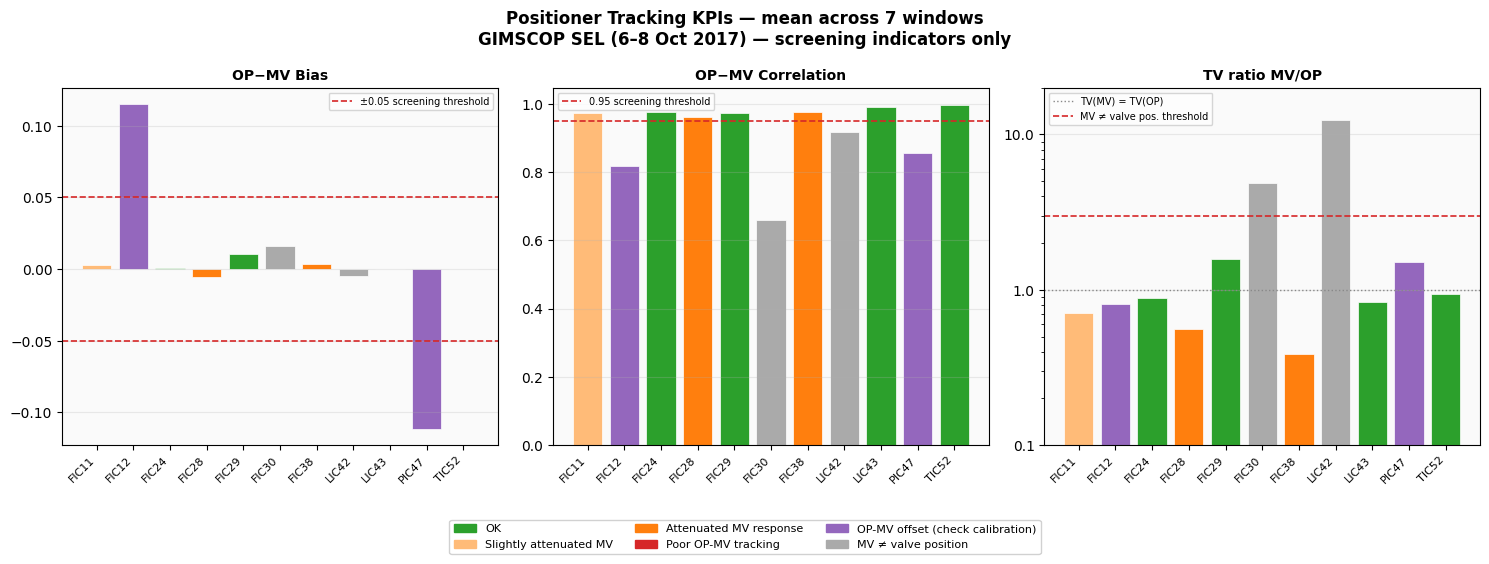

Figure saved → outputs\figures\cpm_positioner_kpis.png


In [17]:
pos_cols  = ["loop_tag", "window",
             "op_mv_bias", "op_mv_mae", "op_mv_corr",
             "tv_mv_op_ratio", "mv_is_valve_position"]
available = [c for c in pos_cols if c in kpi_windows.columns]
pos_df    = kpi_windows[available].copy()

pos_agg = (
    pos_df.groupby("loop_tag")
    .agg({"op_mv_bias":           "mean",
          "op_mv_mae":            "mean",
          "op_mv_corr":           "mean",
          "tv_mv_op_ratio":       "mean",
          "mv_is_valve_position": "first"})
    .round(4)
    .reset_index()
)

# Cautious classification — screening labels, not confirmed diagnoses
def positioner_status(row):
    if row["mv_is_valve_position"] == False:
        return "MV ≠ valve position"
    if abs(row["op_mv_bias"]) > 0.05:
        return "OP-MV offset (check calibration)"
    if row["op_mv_corr"] < 0.95:
        return "Poor OP-MV tracking"
    if row["tv_mv_op_ratio"] < 0.60:
        return "Attenuated MV response"
    if row["tv_mv_op_ratio"] < 0.80:
        return "Slightly attenuated MV"
    return "OK"

pos_agg["positioner_status"] = pos_agg.apply(positioner_status, axis=1)

print("Positioner tracking summary (mean across 7 windows):")
print("Note: these are screening indicators — plant verification required to confirm root cause.\n")
display(pos_agg.sort_values("op_mv_corr"))

STATUS_COLORS = {
    "OK":                             "#2ca02c",
    "Slightly attenuated MV":         "#ffbb78",
    "Attenuated MV response":         "#ff7f0e",
    "Poor OP-MV tracking":            "#d62728",
    "OP-MV offset (check calibration)": "#9467bd",
    "MV ≠ valve position":            "#aaaaaa",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Positioner Tracking KPIs — mean across 7 windows\n"
             "GIMSCOP SEL (6–8 Oct 2017) — screening indicators only",
             fontsize=12, fontweight="bold")

metrics = [
    ("op_mv_bias",     "OP−MV Bias",        0.05, "±0.05 screening threshold"),
    ("op_mv_corr",     "OP−MV Correlation", 0.95, "0.95 screening threshold"),
    ("tv_mv_op_ratio", "TV ratio MV/OP",    None, None),
]

for ax, (col, title, thr, thr_label) in zip(axes, metrics):
    colors = [STATUS_COLORS.get(s, "#4393c3")
              for s in pos_agg["positioner_status"]]
    vals   = pos_agg[col].values
    tags   = pos_agg["loop_tag"].values

    ax.bar(range(len(tags)), vals, color=colors,
           edgecolor="white", linewidth=0.5)

    if thr is not None:
        ax.axhline( thr, color="#d62728", lw=1.2, ls="--", label=thr_label)
        if col == "op_mv_bias":
            ax.axhline(-thr, color="#d62728", lw=1.2, ls="--")

    if col == "tv_mv_op_ratio":
        ax.set_yscale("log")
        ax.set_ylim(0.1, 20)
        ax.axhline(1.0, color="#888", lw=1.0, ls=":", label="TV(MV) = TV(OP)")
        ax.axhline(3.0, color="#d62728", lw=1.2, ls="--",
                   label="MV ≠ valve pos. threshold")
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda y, _: f"{y:.1f}"))

    ax.set_xticks(range(len(tags)))
    ax.set_xticklabels(tags, rotation=45, ha="right", fontsize=8)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.legend(fontsize=7)
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_facecolor("#fafafa")

legend_patches = [mpatches.Patch(color=v, label=k)
                  for k, v in STATUS_COLORS.items()]
fig.legend(handles=legend_patches, fontsize=8, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.12), framealpha=0.9, edgecolor="#ccc")
plt.tight_layout()
out = FIG_DIR / "cpm_positioner_kpis.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved → {out}")


### 13.4 Time-series inspection — highlighted loops

Two loops are selected for detailed inspection based on their KPI profiles:

**FIC28** — highest OI_reg values in the dataset (up to 10.72 in windows 3–6).
OI_zc remains moderate (~0.07–0.15), illustrating that OI_reg detects genuine
regular oscillations that the zero-crossing index alone would miss. The SP follows
PV closely (cascade slave), suggesting the oscillation originates in the master loop.
Additionally, tv_mv_op_ratio = 0.56 indicates that the valve travels only 56% of
what the controller commands — consistent with mechanical friction (stiction).
This combination of cascade-propagated oscillation and attenuated valve response
makes FIC28 a multi-cause loop: addressing the oscillation requires acting on the
master loop, while the valve condition requires independent maintenance assessment.

**LIC42** — level controller with growing oscillation amplitude over time.
OI_reg > 1 in most windows, with a noticeable deterioration in IAE_norm from W4
onwards (+0.14 → +0.26 bias). SP is constant (set once and unchanged for 60 h),
confirming pure feedback control. The progressive amplitude increase is
characteristic of an over-tuned integrating process approaching its stability
boundary.

Note: the MV signal for LIC42 shows tv_mv_op_ratio = 12.2, indicating that MV
is not the physical valve position but a downstream process measurement oscillating
independently of the controller output. Positioner diagnostics are therefore not
applicable to this loop.


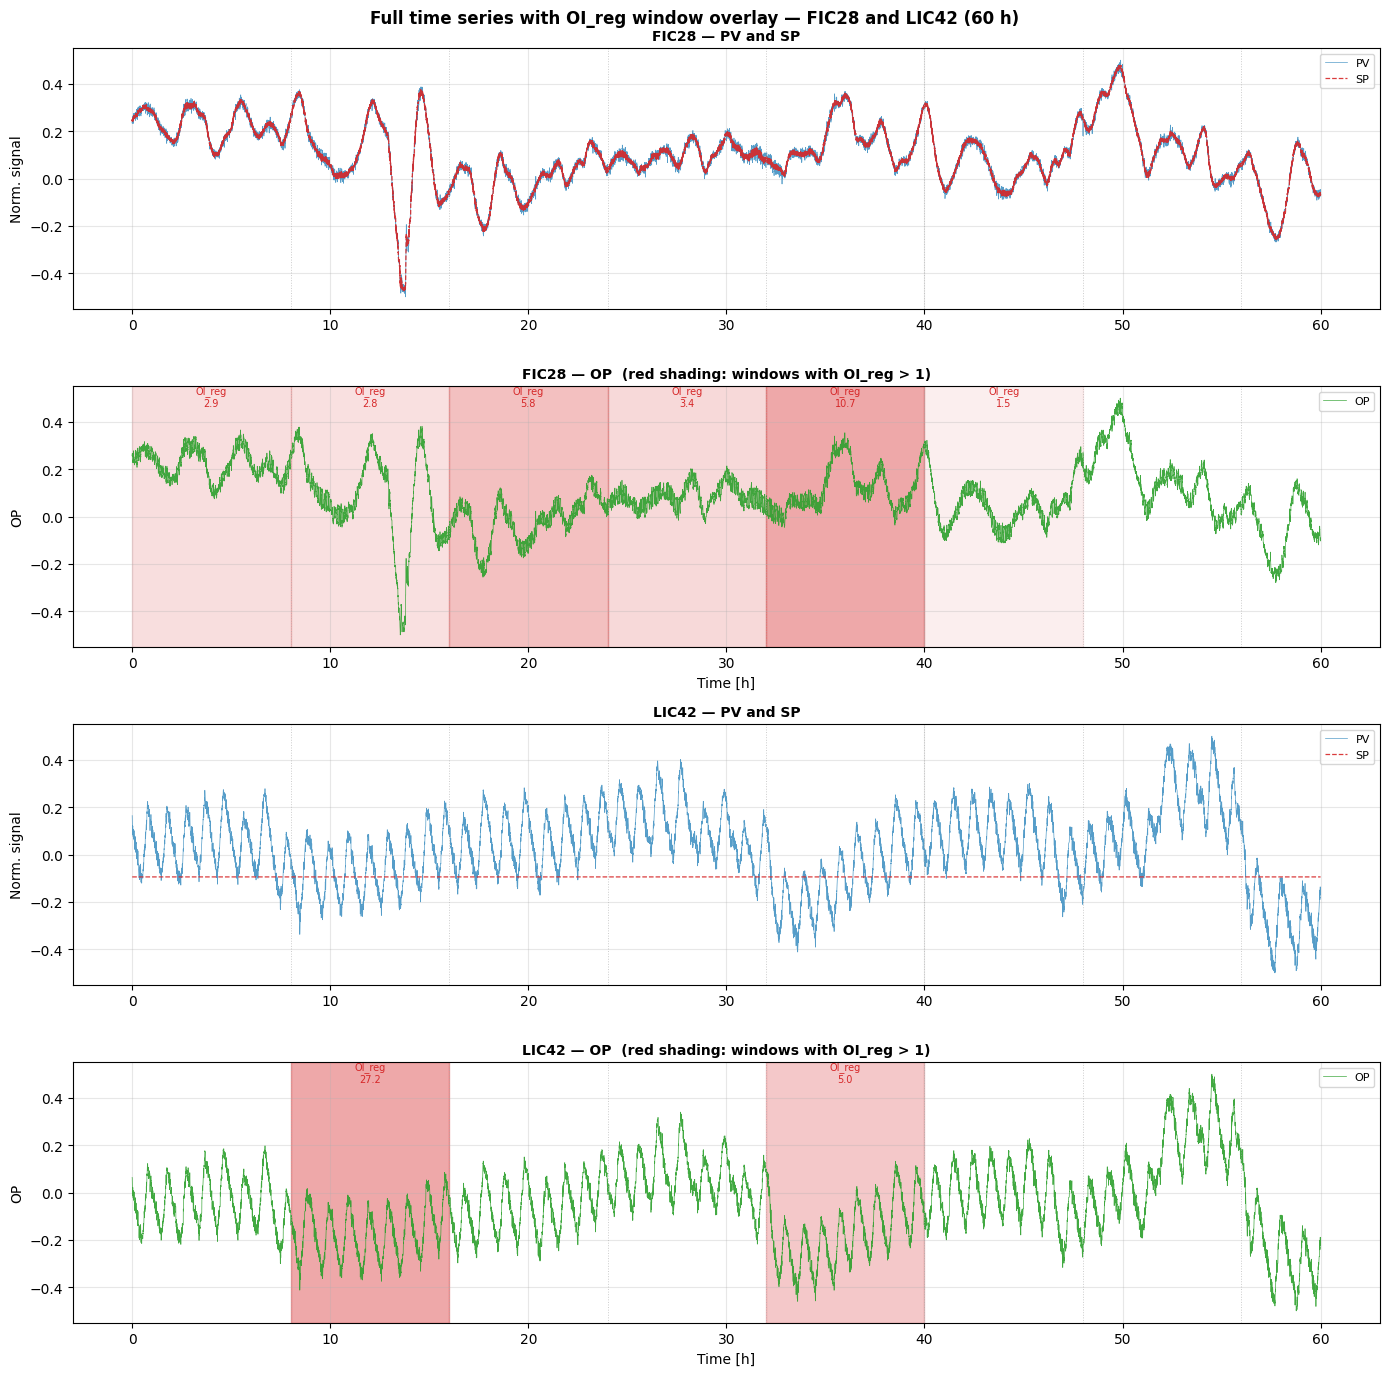

Figure saved → outputs\figures\cpm_timeseries_highlights.png


In [18]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=False)
fig.suptitle("Full time series with OI_reg window overlay — FIC28 and LIC42 (60 h)",
             fontsize=12, fontweight="bold")

for row_idx, tag in enumerate(["FIC28", "LIC42"]):
    df = resample_to_grid(load_sel_loop(tag))
    t  = df.index * DT_SECONDS / 3600

    ax_pv = axes[row_idx * 2]
    ax_pv.plot(t, df["PV"], lw=0.5, color="#4393c3", label="PV", alpha=0.9)
    ax_pv.plot(t, df["SP"], lw=0.9, ls="--", color="#d62728", label="SP", alpha=0.9)
    for w in range(1, 8):
        ax_pv.axvline(w * WINDOW_H, color="#aaa", lw=0.7, ls=":", alpha=0.6)
    ax_pv.set_title(f"{tag} — PV and SP", fontsize=10, fontweight="bold")
    ax_pv.set_ylabel("Norm. signal"); ax_pv.legend(fontsize=8)
    ax_pv.grid(True, alpha=0.3)

    ax_op = axes[row_idx * 2 + 1]
    ax_op.plot(t, df["OP"], lw=0.5, color="#2ca02c", label="OP", alpha=0.9)

    loop_kpis = kpi_windows[kpi_windows["loop_tag"] == tag]
    for _, krow in loop_kpis.iterrows():
        oi_reg = krow["oi_reg_plot"]   # use capped version for shading intensity
        if pd.notna(oi_reg) and oi_reg > 1.0:
            ax_op.axvspan(krow["window_start_h"], krow["window_end_h"],
                          alpha=min(oi_reg / 20.0, 0.40), color="#d62728")
            mid  = (krow["window_start_h"] + krow["window_end_h"]) / 2
            ylim = ax_op.get_ylim()
            # Show raw OI_reg in label for full information
            raw_val = krow["oi_reg_raw"]
            label   = f"OI_reg\n{raw_val:.1f}" if pd.notna(raw_val) else f"OI_reg\n{oi_reg:.1f}"
            ax_op.text(mid, ylim[1] * 0.85 if ylim[1] > 0 else 0.3,
                       label, fontsize=7, color="#d62728", ha="center")

    for w in range(1, 8):
        ax_op.axvline(w * WINDOW_H, color="#aaa", lw=0.7, ls=":", alpha=0.6)
    ax_op.set_title(f"{tag} — OP  (red shading: windows with OI_reg > 1)",
                    fontsize=10, fontweight="bold")
    ax_op.set_ylabel("OP"); ax_op.set_xlabel("Time [h]")
    ax_op.legend(fontsize=8); ax_op.grid(True, alpha=0.3)

plt.tight_layout()
out = FIG_DIR / "cpm_timeseries_highlights.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved → {out}")


## 14. Export Results

In [19]:
# ── 14.1  Windowed KPI table ─────────────────────────────────────────────────
out_csv = OUTPUTS_DIR / "cpm_kpi_windows.csv"
kpi_windows.to_csv(out_csv, index=False, float_format="%.6f")
print(f"Windowed KPI table → {out_csv}")
print(f"  {len(kpi_windows)} rows × {len(kpi_windows.columns)} columns")
print(f"  Columns: {list(kpi_windows.columns)}")

# ── 14.2  Loop-level summary ──────────────────────────────────────────────────
loop_summary = (
    kpi_windows
    .groupby("loop_tag")
    .agg(
        mean_oi_zc        =("oi_zc",          "mean"),
        max_oi_zc         =("oi_zc",          "max"),
        mean_oi_reg       =("oi_reg_plot",     "mean"),
        max_oi_reg        =("oi_reg_plot",     "max"),
        max_oi_reg_raw    =("oi_reg_raw",      "max"),
        mean_p_osc        =("p_osc",           "mean"),
        mean_iae_norm     =("iae_norm",        "mean"),
        max_abs_bias      =("bias",    lambda x: x.abs().max()),
        bias_std          = ("bias",            "std"),
        mean_sp_std       = ("sp_std",          "mean"),
        mean_tv_op_norm   =("tv_op_norm",      "mean"),
        mean_op_mv_mae    =("op_mv_mae",       "mean"),
        mean_tv_mv_ratio  =("tv_mv_op_ratio",  "mean"),
    )
    .round(4)
    .reset_index()
)

out_summary = OUTPUTS_DIR / "cpm_loop_summary.csv"
loop_summary.to_csv(out_summary, index=False, float_format="%.6f")
print(f"\nLoop summary → {out_summary}")
display(loop_summary)

# ── 14.3  Diagnosis flags ─────────────────────────────────────────────────────
def assign_diagnosis(row):
    """
    Heuristic screening flags based on KPI thresholds.
    These are indicators to prioritise loops for further review,
    not definitive root-cause diagnoses.
    """
    flags = []

    # Regular oscillation: OI_reg > 1.0 AND P_osc > 10%
    if (pd.notna(row.get("oi_reg")) and row.get("oi_reg", 0) > 1.0
            and pd.notna(row.get("p_osc")) and row.get("p_osc", 0) > 10.0):
        flags.append("regular_oscillation")

    # High-frequency activity: OI_zc > 0.25
    if pd.notna(row.get("oi_zc")) and row.get("oi_zc", 0) > 0.25:
        flags.append("high_frequency_activity")

    # Tracking bias: |bias| > 0.10
    if pd.notna(row.get("bias")) and abs(row.get("bias", 0)) > 0.10:
        flags.append("tracking_bias")

    # High tracking error: IAE_norm > 2.0
    if pd.notna(row.get("iae_norm")) and row.get("iae_norm", 0) > 2.0:
        flags.append("high_tracking_error")

    # Attenuated MV response (possible stiction): TV_ratio < 0.60
    if (pd.notna(row.get("tv_mv_op_ratio"))
            and row.get("mv_is_valve_position") == True
            and row.get("tv_mv_op_ratio", 1) < 0.60):
        flags.append("attenuated_mv_response")

    # Slightly attenuated MV: 0.60 ≤ TV_ratio < 0.80
    elif (pd.notna(row.get("tv_mv_op_ratio"))
            and row.get("mv_is_valve_position") == True
            and row.get("tv_mv_op_ratio", 1) < 0.80):
        flags.append("slightly_attenuated_mv")

    # OP-MV offset: |op_mv_bias| > 0.05
    if pd.notna(row.get("op_mv_bias")) and abs(row.get("op_mv_bias", 0)) > 0.05:
        flags.append("op_mv_offset")

    # Empirical OP bound behaviour: op_sat_frac > 0.20
    if pd.notna(row.get("op_sat_frac")) and row.get("op_sat_frac", 0) > 0.20:
        flags.append("empirical_op_bound")

    return ", ".join(flags) if flags else "normal_or_low_priority"

kpi_windows["diagnosis_flags"] = kpi_windows.apply(assign_diagnosis, axis=1)

out_flags = OUTPUTS_DIR / "cpm_kpi_windows_flagged.csv"
kpi_windows.to_csv(out_flags, index=False, float_format="%.6f")
print(f"\nFlagged KPI table → {out_flags}")
print("\nDiagnosis flag summary (count per flag across all windows):")
all_flags = [f for flags in kpi_windows["diagnosis_flags"] for f in flags.split(", ")]
print(pd.Series(all_flags).value_counts().to_string())


Windowed KPI table → outputs\cpm_kpi_windows.csv
  77 rows × 31 columns
  Columns: ['loop_tag', 'pv_mean', 'pv_std', 'sp_coverage', 'oi_zc', 'oscillation_period_s', 'oi_reg', 'period_std_s', 'p_osc', 'tv_op_abs', 'tv_op_norm', 'op_sat_frac', 'op_direction_changes', 'op_direction_change_rate', 'mae', 'rmse', 'bias', 'iae_norm', 'sp_std', 'sp_mean', 'op_mv_bias', 'op_mv_mae', 'op_mv_corr', 'tv_mv_op_ratio', 'mv_is_valve_position', 'window', 'window_start_h', 'window_end_h', 'sp_rescaled', 'oi_reg_raw', 'oi_reg_plot']

Loop summary → outputs\cpm_loop_summary.csv


,loop_tag,mean_oi_zc,max_oi_zc,mean_oi_reg,max_oi_reg,max_oi_reg_raw,mean_p_osc,mean_iae_norm,max_abs_bias,bias_std,mean_sp_std,mean_tv_op_norm,mean_op_mv_mae,mean_tv_mv_ratio
0,FIC11,0.0703,0.0829,8.4905,20.0000,20.0499,23.6840,0.3143,0.0020,0.0010,0.1024,0.0160,0.0199,0.7139
1,FIC12,0.0615,0.0903,1.5829,2.8076,2.8076,18.0814,0.4173,0.0020,0.0015,0.0664,0.0130,0.1187,0.8121
2,FIC24,0.1109,0.1840,5.8868,20.0000,30.4118,30.9594,0.4919,0.0041,0.0023,0.0791,0.0133,0.0087,0.8795
3,FIC28,0.0111,0.0232,4.0317,10.7203,10.7203,59.2978,0.0942,0.0004,0.0002,0.1004,0.0054,0.0188,0.5570
4,FIC29,0.0707,0.1288,NaN,NaN,NaN,11.1794,1.3162,0.0878,0.0087,0.0834,0.0062,0.0124,1.5829
5,FIC30,0.0455,0.0611,8.4679,20.0000,55593000000000.0078,50.6229,0.5700,0.0020,0.0012,0.0672,0.0052,0.0481,4.8409
6,FIC38,0.0406,0.0558,3.7491,3.7491,3.7491,32.6551,0.9035,0.1041,0.0471,0.1319,0.0077,0.0301,0.3884
7,LIC42,0.0042,0.0051,12.5117,20.0000,27.2048,67.6179,1.3693,0.2593,0.0884,0.0000,0.0031,0.0395,12.2998
8,LIC43,0.0011,0.0034,0.6322,0.7298,0.7298,27.0173,0.0097,0.0001,0.0001,0.0781,0.0135,0.0058,0.8317
9,PIC47,0.0292,0.0376,1.2480,1.2480,1.2480,30.7361,0.9885,0.0807,0.0018,0.0000,0.0045,0.1257,1.5169



Flagged KPI table → outputs\cpm_kpi_windows_flagged.csv

Diagnosis flag summary (count per flag across all windows):
regular_oscillation       34
normal_or_low_priority    17
op_mv_offset              14
attenuated_mv_response    14
slightly_attenuated_mv    12
tracking_bias              6
high_tracking_error        2


---
## Summary and Key Findings

This notebook computed a comprehensive set of CPM KPIs for 11 SISO industrial
control loops from the GIMSCOP SEL dataset, using 7 non-overlapping 8-hour windows
per loop (77 observations total).

### Data quality
- All loops normalised to [−0.5, 0.5] for PV, OP, MV
- SP rescaling applied to FIC29 and FIC38 (non-normalised at historian source)
- SP constant throughout 60 h for LIC42 and PIC47 (setpoint unchanged — valid)

### Key observations

**Oscillation:**
- No loop exceeds the OI_zc threshold of 0.30 in this contemporaneous subset.
  OI_zc is most sensitive to rapid cycling; slow process oscillations produce
  low OI_zc values even when the oscillation is real and energetic.
- **FIC11** and **FIC28** show persistently high OI_reg (> 2 throughout all windows)
  despite moderate OI_zc — demonstrating that the regularity index detects genuine
  regular oscillations that the zero-crossing rate misses
- **FIC28** reaches OI_reg = 10.72 in windows 3–6, indicating an extremely regular
  oscillation consistent with propagation from an oscillating cascade master loop

**Tracking:**
- **LIC42**: growing positive bias over time (+0.14 → +0.26), consistent with a
  progressively destabilising over-tuned integrating process
- Most flow controllers (FIC11, FIC12, FIC24, FIC28, FIC30) show near-zero bias
  across all windows

**Valve activity:**
- TV_norm < 0.08 for all loops in all windows — no excessive valve travel detected

**Positioner diagnostics (screening indicators — plant verification required):**
- **FIC12** and **PIC47**: OP−MV offset |bias| > 0.11 — OP and MV diverge
  systematically, possibly consistent with a calibration mismatch or signal
  definition difference between controller output and valve feedback
- **FIC38**, **FIC28**, **FIC11**: TV_ratio(MV/OP) < 0.80 — MV travels less
  than commanded, possibly consistent with mechanical friction in the actuator.
  FIC38 is the most pronounced case (TV_ratio = 0.39)
- **LIC42** and **FIC30**: TV_ratio >> 1 (12.2 and 4.8 respectively) — MV is
  likely not the physical valve position but a downstream process measurement.
  Positioner diagnostics are not applicable to these loops
- **LIC43** and **TIC52**: corr ≈ 1.00, TV_ratio ≈ 0.94 — OP and MV behave
  consistently

### Limitations
1. Process topology (loop interconnections, utility sharing) is not documented
   in the dataset — formal CCF and RGA analysis of multi-loop interactions
   requires this information
2. SP rescaling for FIC29 and FIC38 introduces an approximation in error-based KPIs
3. The 8-hour window discards ~4 h of data at the end of the record
4. No controller MODE signal is available — manual-mode periods cannot be excluded
5. MV is used for positioner diagnostics when available. For LIC42 and FIC30,
   tv_mv_op_ratio >> 1 indicates MV is not the physical valve position —
   positioner KPIs are flagged as not applicable for these loops
6. op_sat_frac uses empirical OP quantiles as proxies for physical controller limits,
   which are not available in the dataset. Values should be interpreted as
   screening indicators of constrained behaviour, not confirmed saturation
7. All positioner KPIs (op_mv_bias, op_mv_corr, tv_mv_op_ratio) are screening
   metrics. Confirming stiction, backlash or calibration faults requires
   additional plant context: valve signatures, maintenance records and P&ID review

---

